In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("happyyang/ucmerced-landuse")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/ucmerced-landuse


In [43]:
import cv2
import os
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from tqdm import tqdm  # pour barre de progression
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [41]:
data_path = "/kaggle/input/ucmerced-landuse/UCMerced_LandUse/Images"
classes = os.listdir(data_path)
print(f"Classes found: {classes}")


Classes found: ['airplane', 'tenniscourt', 'river', 'denseresidential', 'parkinglot', 'storagetanks', 'overpass', 'sparseresidential', 'mediumresidential', 'intersection', 'baseballdiamond', 'runway', 'chaparral', 'freeway', 'beach', 'buildings', 'harbor', 'mobilehomepark', 'forest', 'golfcourse', 'agricultural']


In [ ]:
# Creates a SIFT detector/descriptor object.
sift = cv2.SIFT_create()

descriptors_list = []
labels = []

for label, scene_class in enumerate(classes):
    class_path = os.path.join(data_path, scene_class)
    
    for img_name in tqdm(os.listdir(class_path), desc=scene_class):
        img_path = os.path.join(class_path, img_name)
        
        img = cv2.imread(img_path)
        if img is None:
            continue
        
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        
        # Detect SIFT keypoints and descriptors
        keypoints, descriptors = sift.detectAndCompute(gray, None)
        
        if descriptors is not None:
            descriptors_list.append(descriptors)
            labels.append(label)

y = np.array(labels)

print(f"✅ Extraction completed — {len(descriptors_list)} images processed.")


agricultural: 100%|██████████| 100/100 [00:03<00:00, 28.88it/s]

✅ Extraction completed — 2096 images processed.


In [5]:
# Descriptor aggregation functions

# Mean, Max, Min

def get_mean_descriptor(desc):
    return desc.mean(axis=0)

def get_max_descriptor(desc):
    return desc.max(axis=0)

def get_min_descriptor(desc):
    return desc.min(axis=0)

# Bag of Visual Words (BoVW)

def build_histogram(descriptors, kmeans_model, k):
    hist = np.zeros(k)
    cluster_result = kmeans_model.predict(descriptors)
    for i in cluster_result:
        hist[i] += 1
    hist = hist / np.linalg.norm(hist)
    return hist

In [ ]:
from sklearn.cluster import KMeans
import numpy as np

# --- A. Mean ---
X_mean = np.array([get_mean_descriptor(d) for d in descriptors_list])

# --- B. Max ---
X_max = np.array([get_max_descriptor(d) for d in descriptors_list])

# --- C. Min ---
X_min = np.array([get_min_descriptor(d) for d in descriptors_list])

# --- D. Bag of Visual Words (BoVW) ---
all_descriptors = np.vstack(descriptors_list)

cluster_numbers = [10, 50, 100, 150]

# Dictionary to store the histograms for each k
bovw_histograms = {}

for k in cluster_numbers:
    print(f"Processing k = {k} clusters...")

    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(all_descriptors)

    X_bovw = np.array([build_histogram(d, kmeans, k) for d in descriptors_list])

    bovw_histograms[k] = X_bovw

print("✅ BoVW histograms built successfully for all k values.")


Processing k = 10 clusters...
Processing k = 50 clusters...
Processing k = 100 clusters...
Processing k = 150 clusters...
✅ BoVW histograms built successfully for all k values.


In [47]:
bovw_histograms[10]
descriptors_dict = {
    "Mean": X_mean,
    "Max": X_max,
    "Min": X_min
}

class_names = sorted([
    d for d in os.listdir(data_path)
    if os.path.isdir(os.path.join(data_path, d))
])

In [ ]:
def evaluate_method(
    X, y, method_name,
    classifier="knn",
    test_sizes=[0.2],
    class_names=None,
    n_neighbors=5,
    random_state=42,
    show_confusion=True,
    show_plot=True
):
    results = {}
    accuracies = []

    for test_size in test_sizes:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state, stratify=y
        )

        # --- Classifier pipeline
        if classifier == "knn":
            clf = Pipeline([
                ("scaler", StandardScaler()),
                ("knn", KNeighborsClassifier(n_neighbors=n_neighbors))
            ])
        elif classifier == "svm":
            clf = Pipeline([
                ("scaler", StandardScaler()),
                ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=random_state))
            ])
        else:
            raise ValueError("Classifier must be 'knn' or 'svm'.")

        # --- Train & predict
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        results[test_size] = acc
        accuracies.append(acc)

        print(f"{method_name} ({classifier.upper()}) — Test {int(test_size*100)}% → 🎯 {acc*100:.2f}%")

        # --- Confusion Matrices ---
        if show_confusion:
            cm = confusion_matrix(y_test, y_pred)
            plt.figure(figsize=(10, 8))
            sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                        xticklabels=class_names, yticklabels=class_names,
                        annot_kws={"size": 7})
            plt.title(f"{method_name} ({classifier.upper()}) | Confusion Matrix ({int(test_size*100)}%)")
            plt.xlabel("Predicted")
            plt.ylabel("True")
            plt.xticks(rotation=45, ha='right', fontsize=8)
            plt.yticks(fontsize=8)
            plt.tight_layout()
            plt.show()

            # Normalized confusion matrix
            cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
            plt.figure(figsize=(10, 8))
            sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Greens",
                        xticklabels=class_names, yticklabels=class_names,
                        annot_kws={"size": 7})
            plt.title(f"{method_name} ({classifier.upper()}) | Normalized ({int(test_size*100)}%)")
            plt.xlabel("Predicted")
            plt.ylabel("True")
            plt.xticks(rotation=45, ha='right', fontsize=8)
            plt.yticks(fontsize=8)
            plt.tight_layout()
            plt.show()

    # --- Plot accuracy vs test size
    if show_plot and len(test_sizes) > 1:
        plt.figure(figsize=(6, 4))
        plt.plot(np.array(test_sizes) * 100, np.array(accuracies) * 100,
                 marker='o', linewidth=2, color='royalblue')
        plt.xlabel("Test size (%)")
        plt.ylabel("Accuracy (%)")
        plt.title(f"{method_name} ({classifier.upper()}) — Accuracy vs Test size")
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.tight_layout()
        plt.show()

    return results


In [45]:
def evaluate_all_methods(
    descriptors_dict,
    y,
    bovw_histograms,
    cluster_numbers,
    test_sizes=[0.2, 0.4],
    class_names=None,
    random_state=42,
    show_confusion=False,
    show_plot=False
):
    results = {'knn': {}, 'svm': {}}

    # --- A. Classic descriptors
    for desc_name, X_desc in tqdm(descriptors_dict.items(), desc="Evaluating classic descriptors"):
        for clf_name in ['knn', 'svm']:
            accs = evaluate_method(
                X_desc, y,
                method_name=f"{desc_name} descriptor",
                classifier=clf_name,
                test_sizes=test_sizes,
                class_names=class_names,
                random_state=random_state,
                show_confusion=show_confusion,
                show_plot=show_plot
            )
            results[clf_name][desc_name] = np.mean(list(accs.values()))

    # --- B. BoVW descriptors
    for k in tqdm(cluster_numbers, desc="Evaluating BoVW histograms"):
        X_bovw = bovw_histograms[k]
        for clf_name in ['knn', 'svm']:
            accs = evaluate_method(
                X_bovw, y,
                method_name=f"BoVW (k={k})",
                classifier=clf_name,
                test_sizes=test_sizes,
                class_names=class_names,
                random_state=random_state,
                show_confusion=show_confusion,
                show_plot=show_plot
            )
            results[clf_name][f"BoVW_k={k}"] = np.mean(list(accs.values()))

    # --- C. Summary Plot
    all_methods = list(results['knn'].keys())
    knn_scores = [results['knn'][m] for m in all_methods]
    svm_scores = [results['svm'][m] for m in all_methods]

    plt.figure(figsize=(12, 6))
    plt.plot(all_methods, knn_scores, 'o-', linewidth=2, label='KNN', color='royalblue')
    plt.plot(all_methods, svm_scores, 's-', linewidth=2, label='SVM', color='darkorange')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Average Accuracy")
    plt.title("Comparison of Descriptors & BoVW (KNN vs SVM)")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- D. Summary Table
    print("\n✅ Evaluation Summary:\n")
    print("{:<20s} {:>10s} {:>10s}".format("Method", "KNN", "SVM"))
    print("-" * 45)
    for m in all_methods:
        print(f"{m:<20s} {results['knn'][m]:.4f} {results['svm'][m]:10.4f}")

    return results

Evaluating classic descriptors:   0%|          | 0/3 [00:00<?, ?it/s]

Mean descriptor (KNN) — Test 20% → 🎯 57.38%


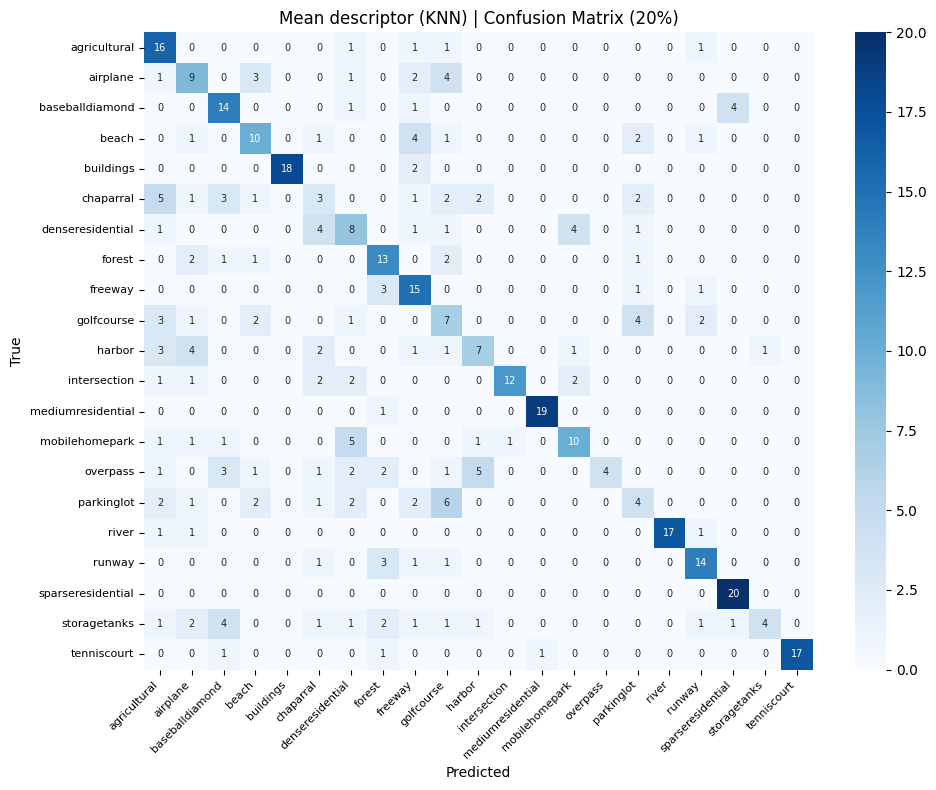

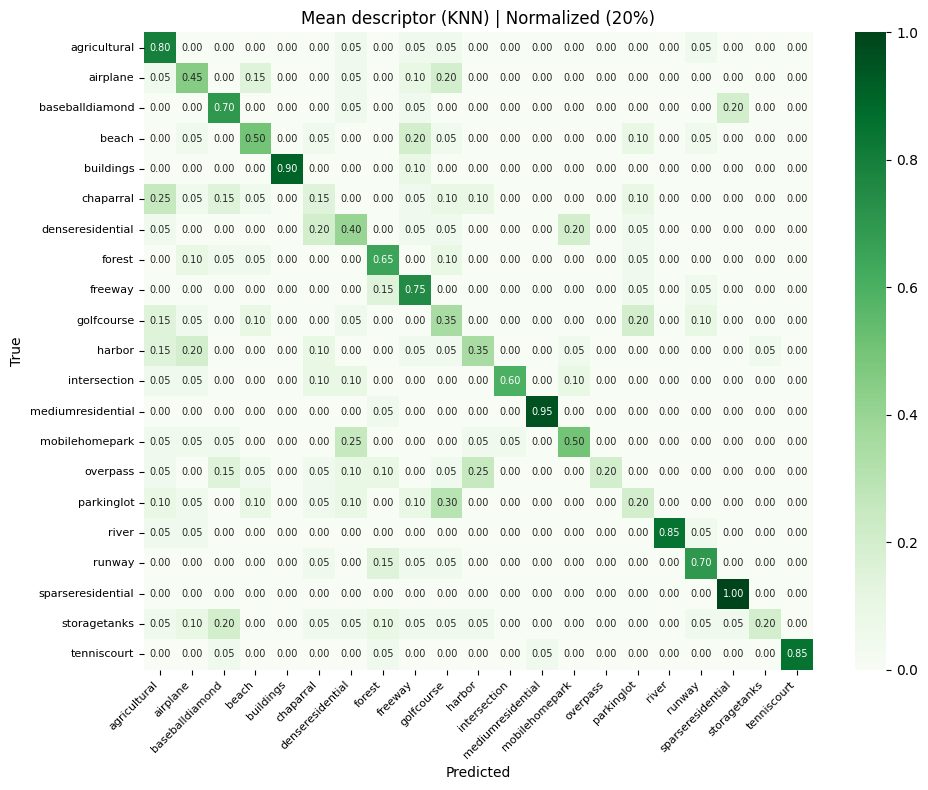

Mean descriptor (KNN) — Test 40% → 🎯 56.02%


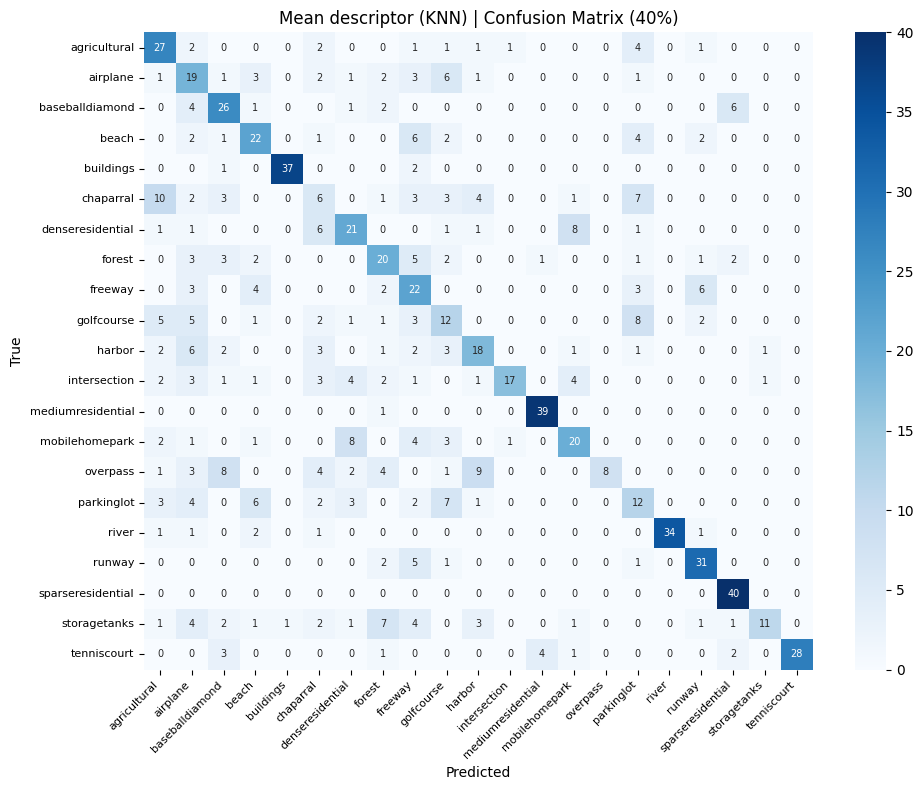

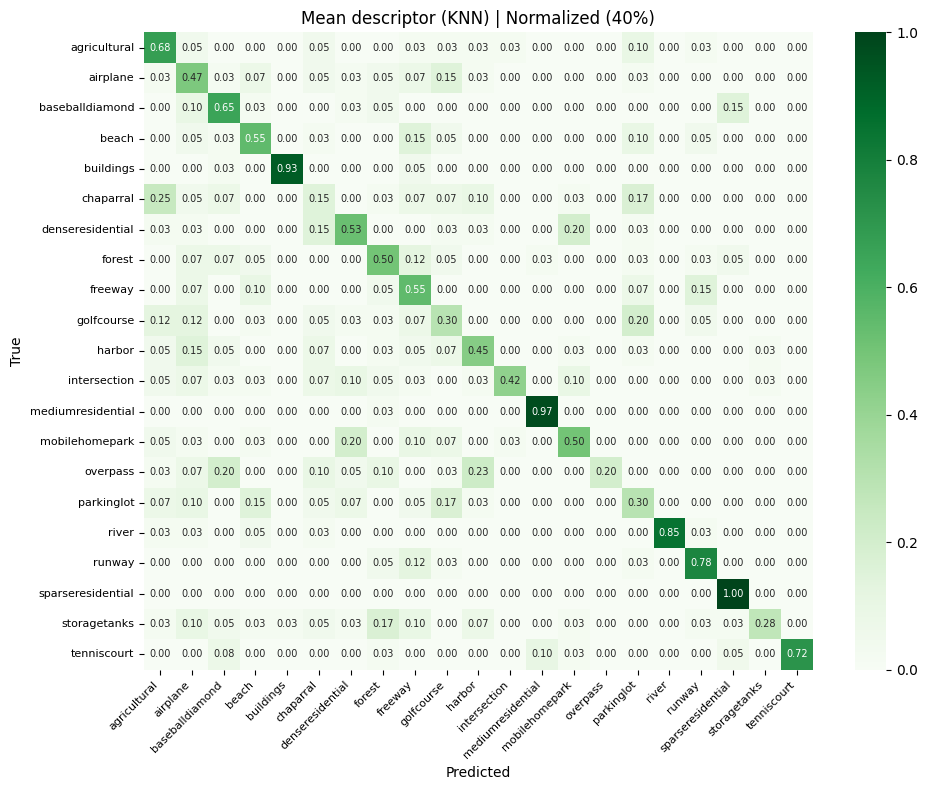

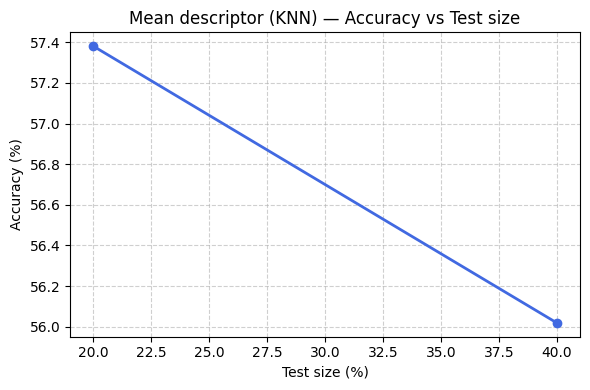

Mean descriptor (SVM) — Test 20% → 🎯 64.05%


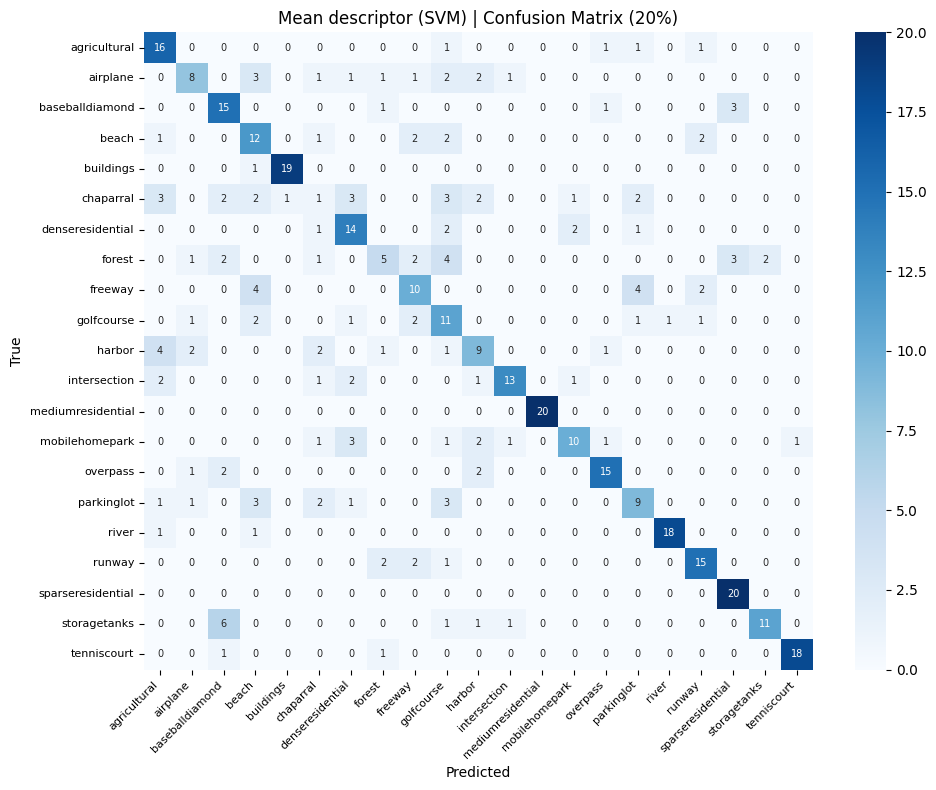

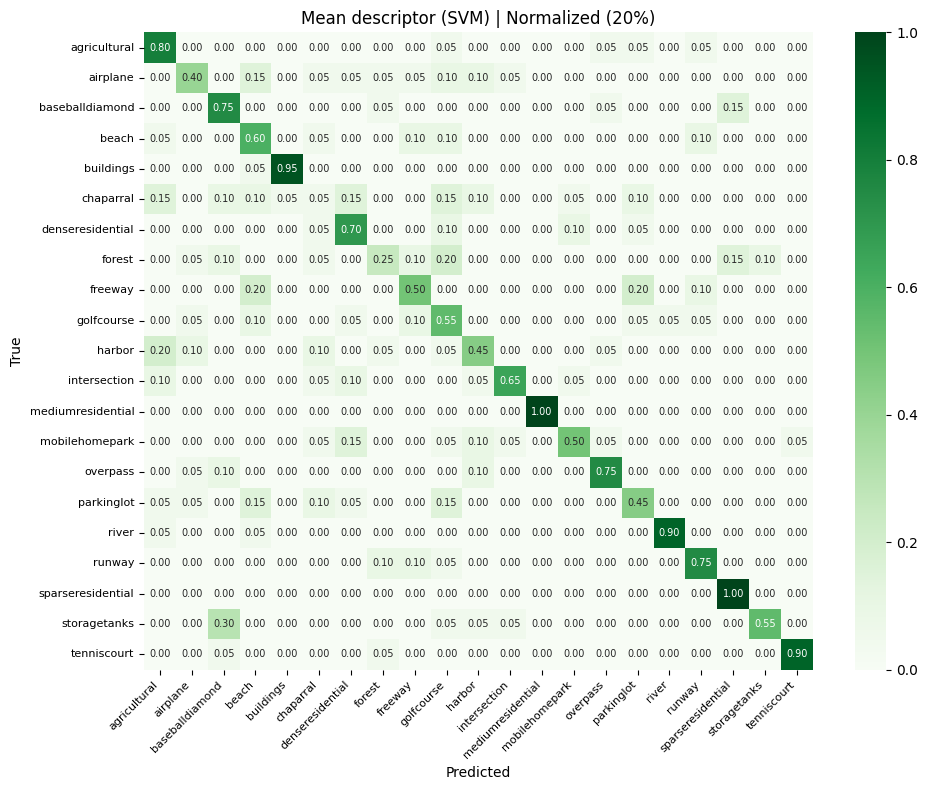

Mean descriptor (SVM) — Test 40% → 🎯 61.50%


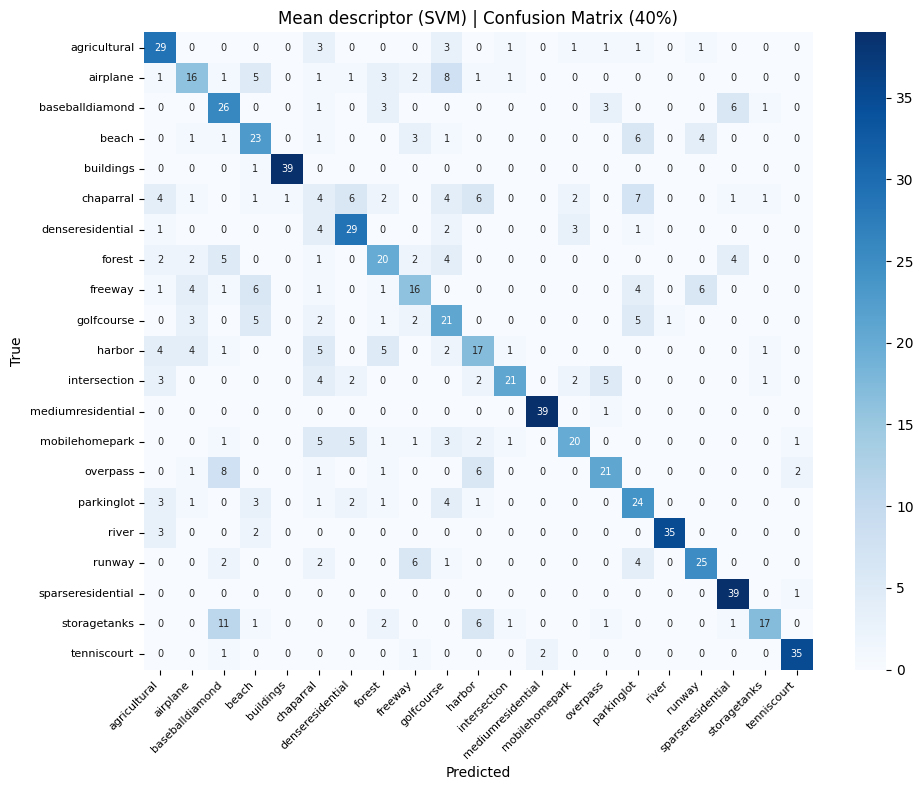

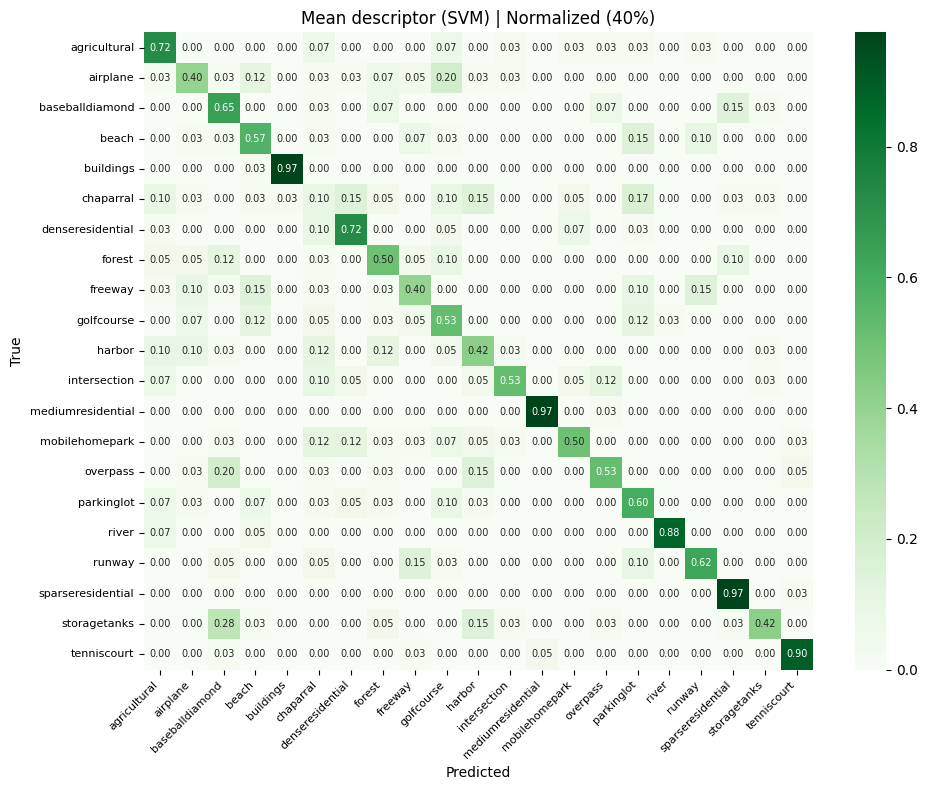

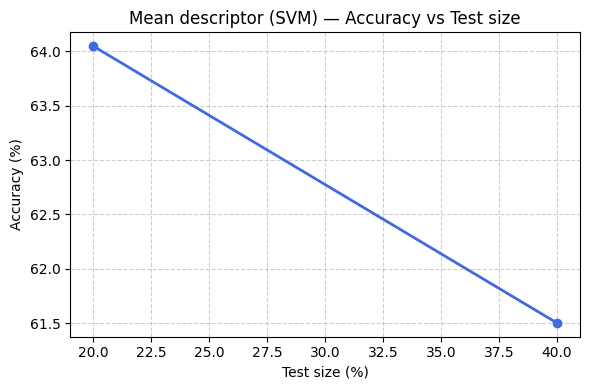

Evaluating classic descriptors:  33%|███▎      | 1/3 [00:08<00:17,  8.80s/it]

Max descriptor (KNN) — Test 20% → 🎯 36.90%


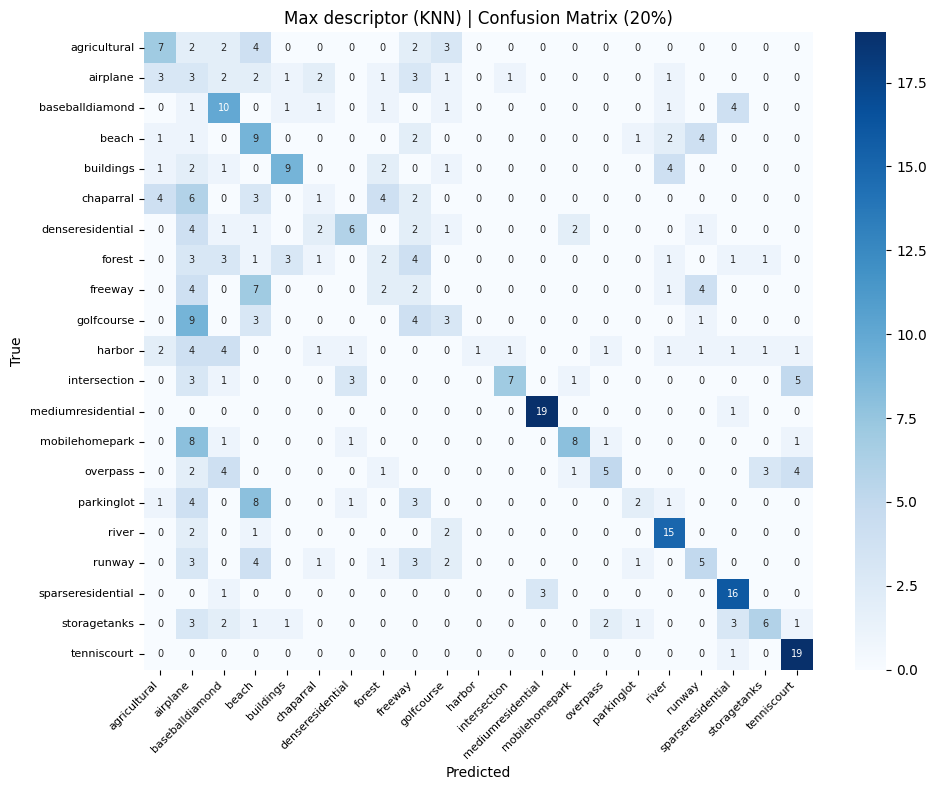

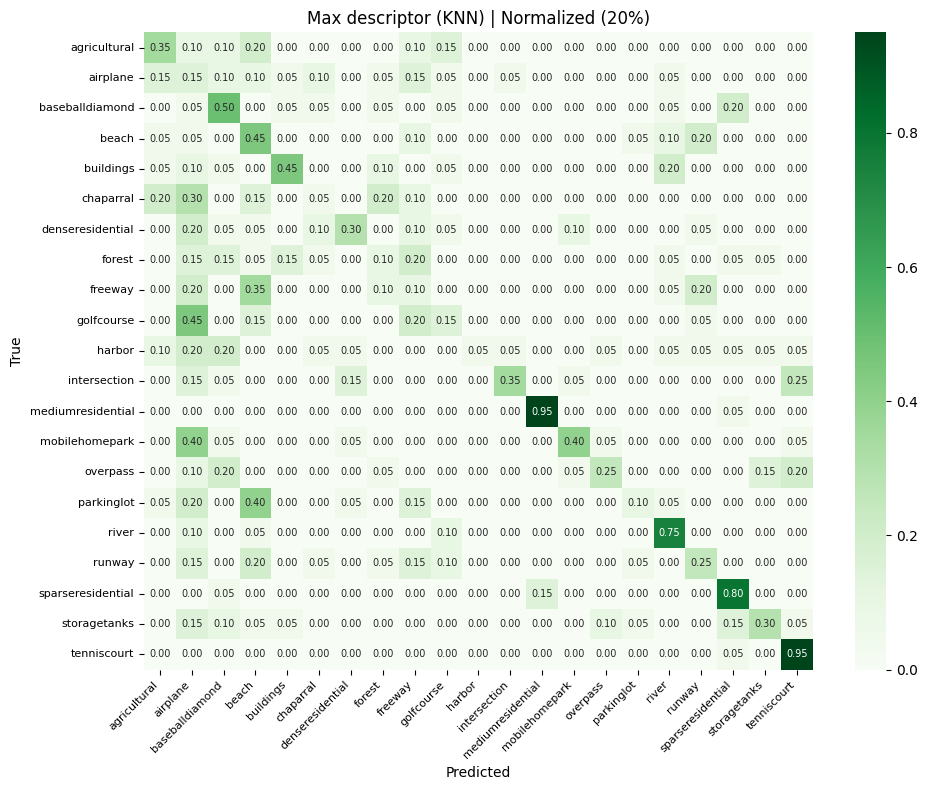

Max descriptor (KNN) — Test 40% → 🎯 34.21%


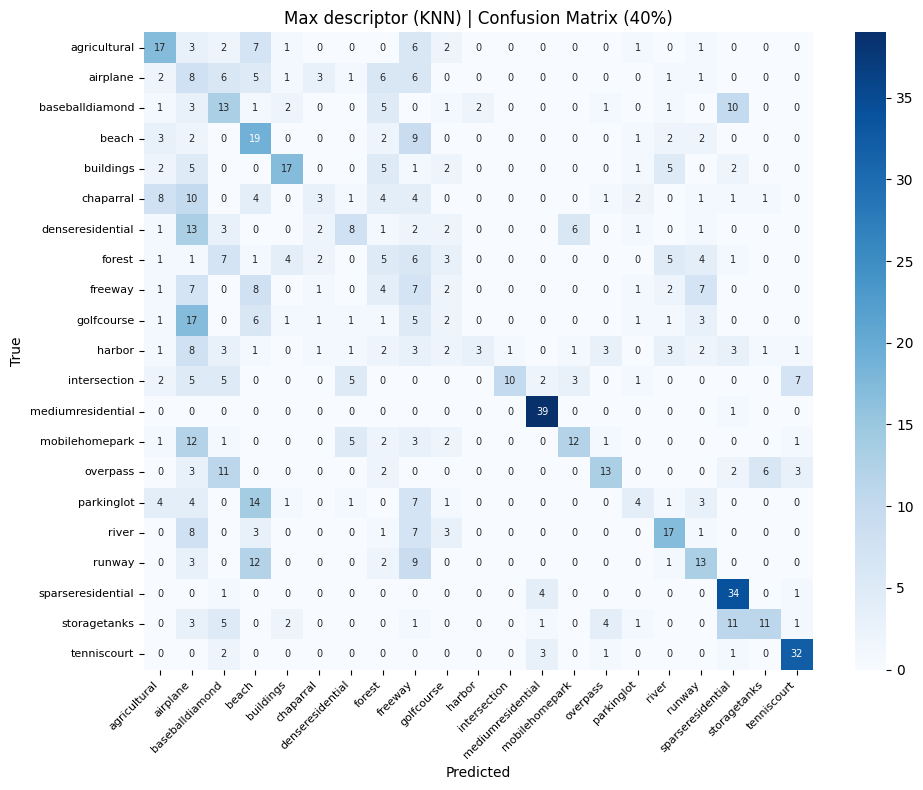

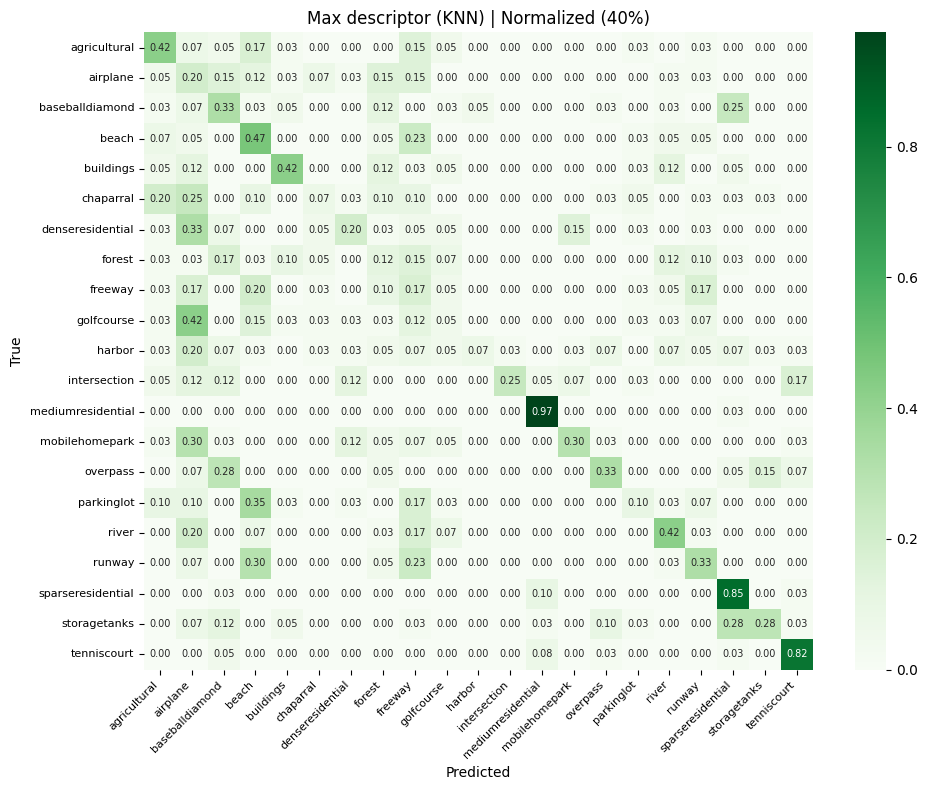

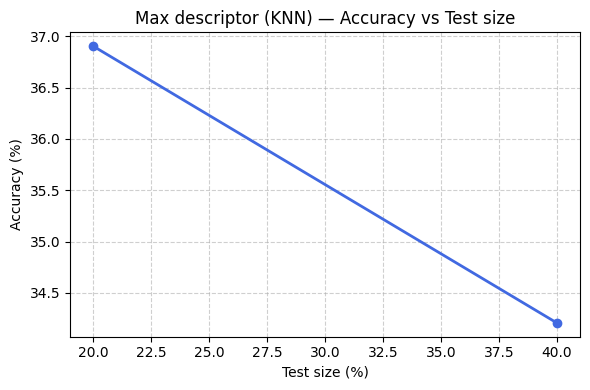

Max descriptor (SVM) — Test 20% → 🎯 49.29%


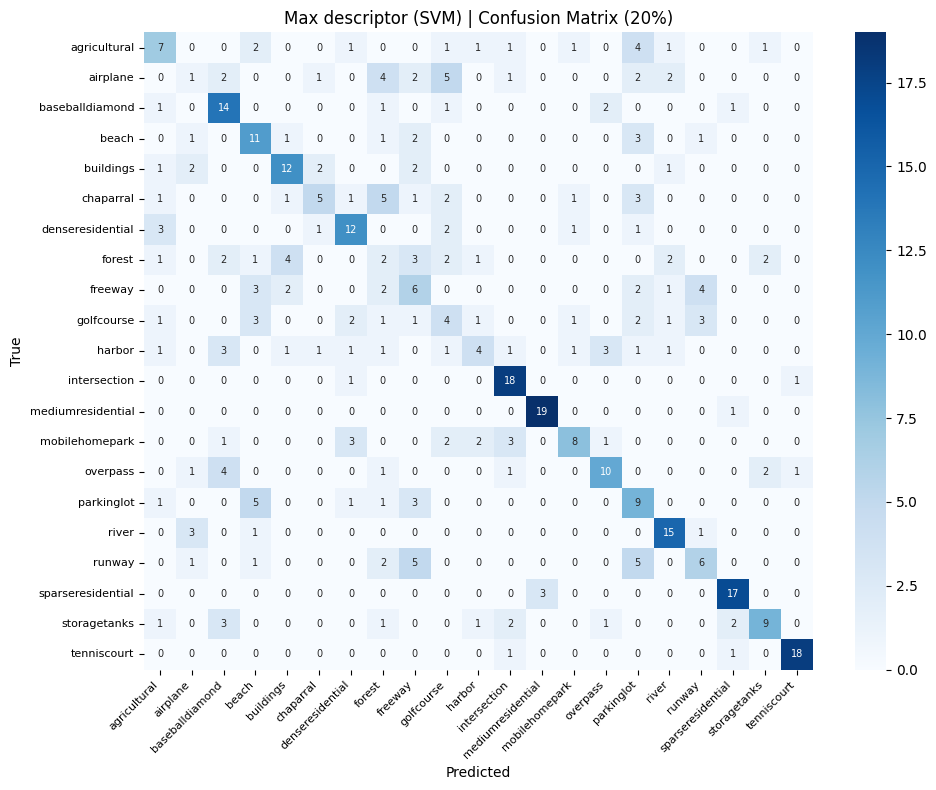

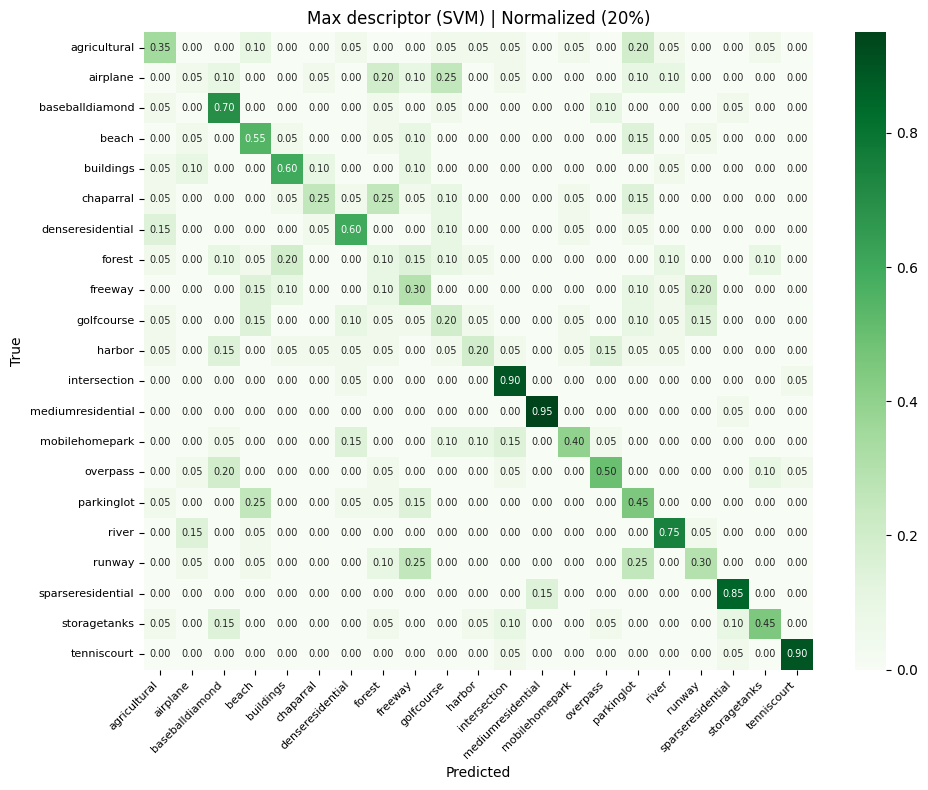

Max descriptor (SVM) — Test 40% → 🎯 47.56%


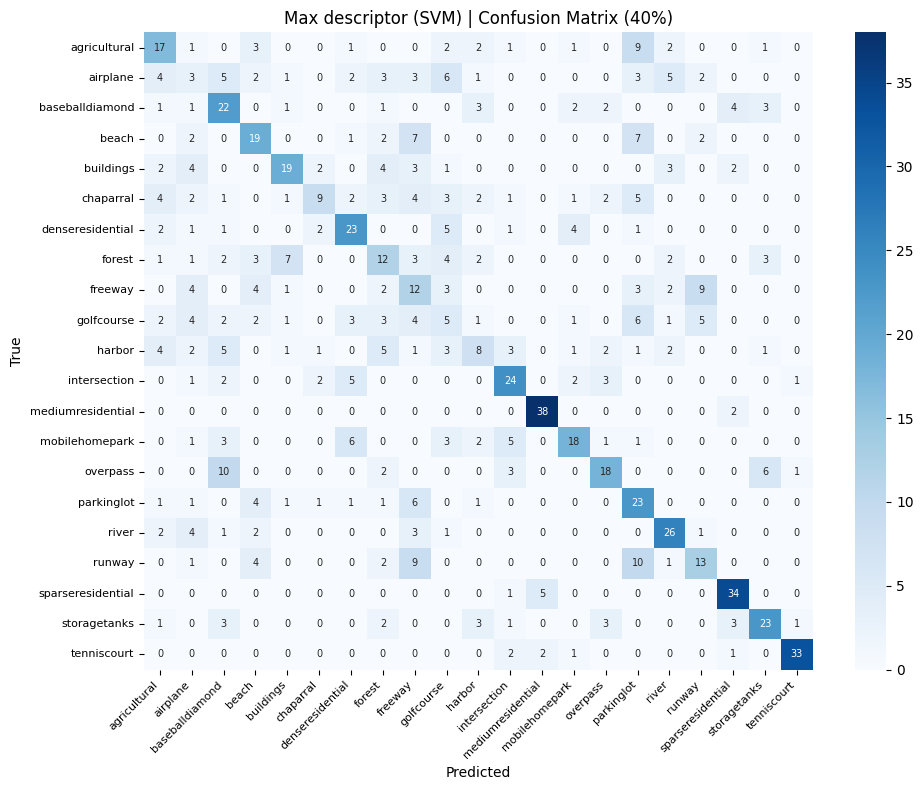

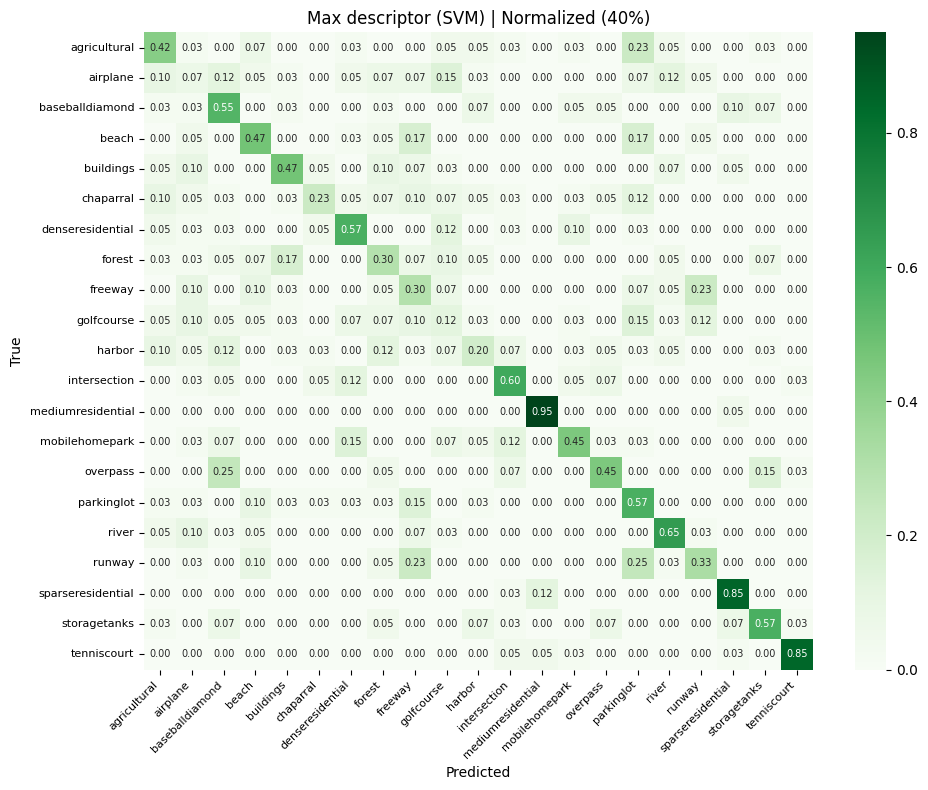

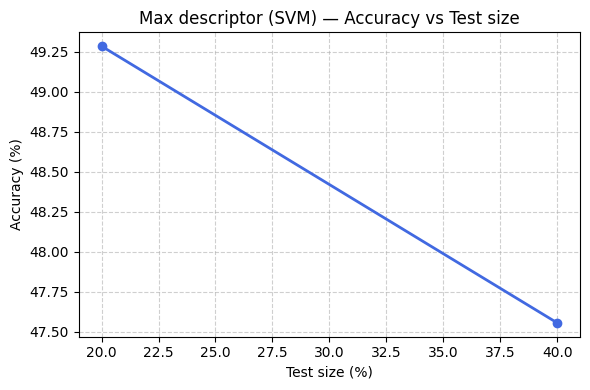

Evaluating classic descriptors:  67%|██████▋   | 2/3 [00:17<00:08,  8.99s/it]

Min descriptor (KNN) — Test 20% → 🎯 17.62%


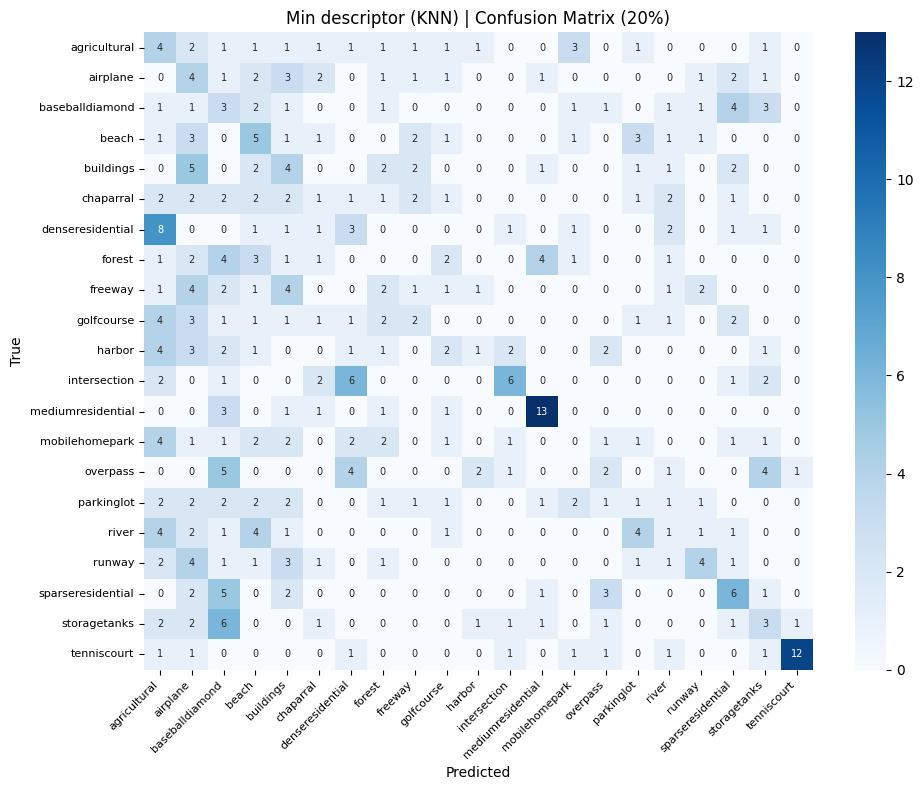

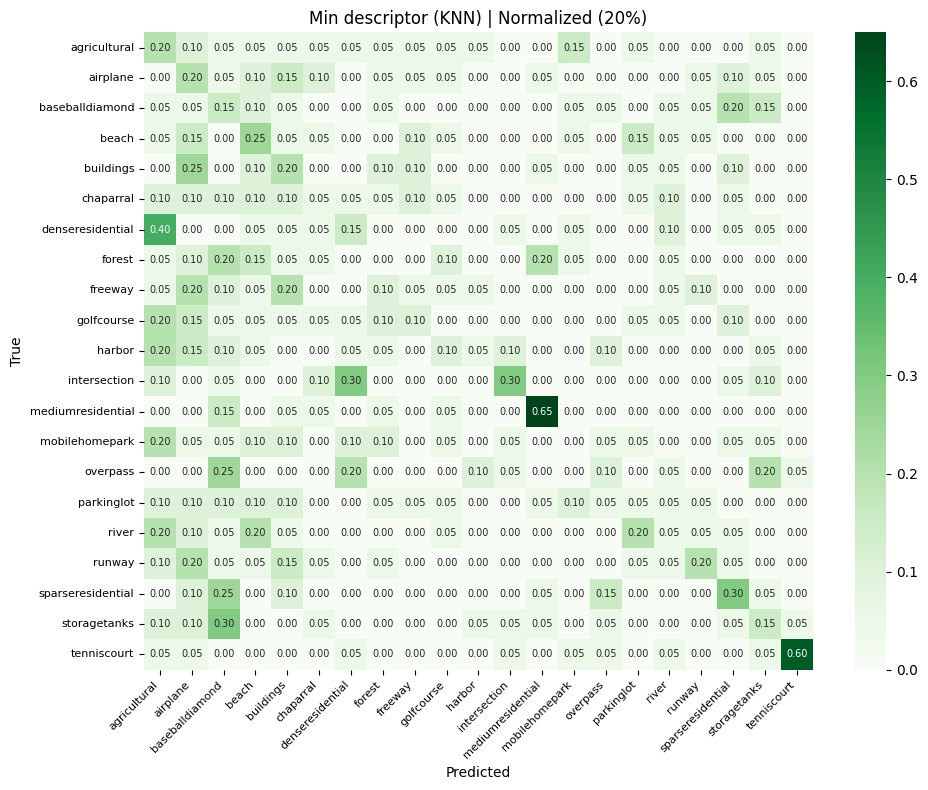

Min descriptor (KNN) — Test 40% → 🎯 18.24%


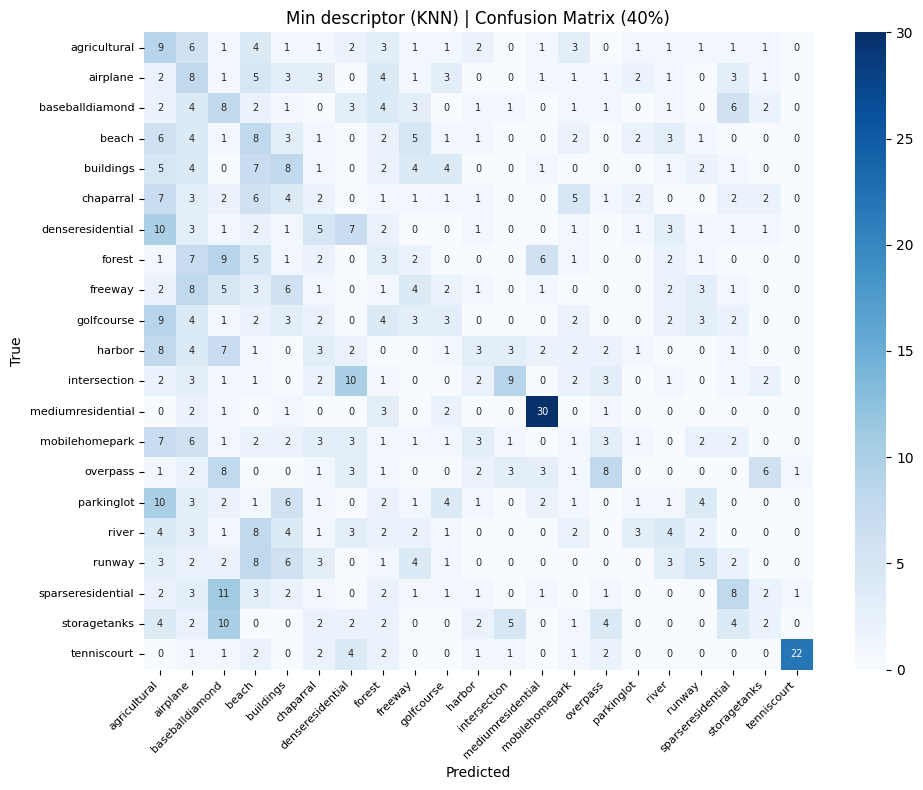

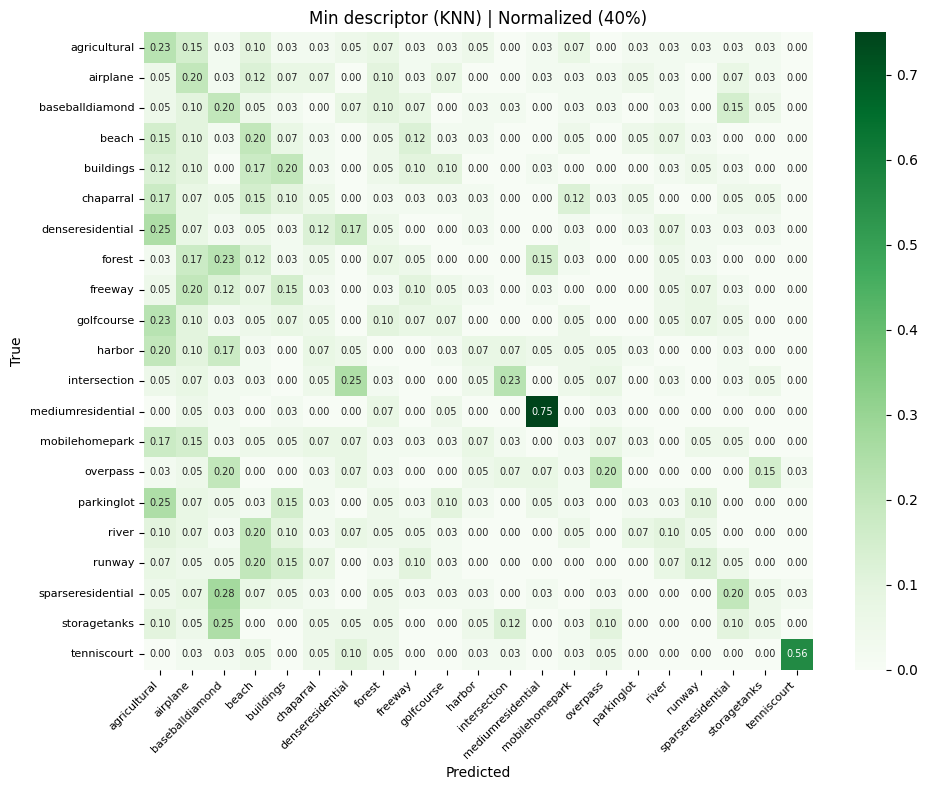

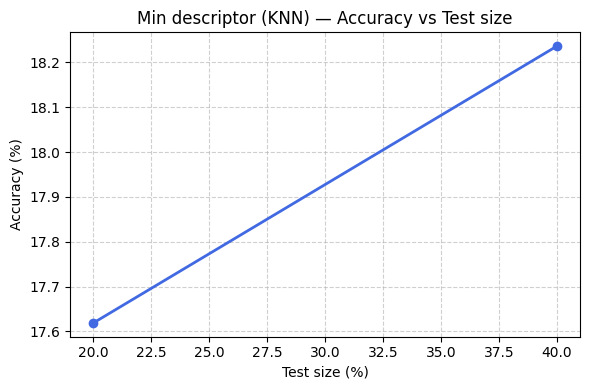

Min descriptor (SVM) — Test 20% → 🎯 12.62%


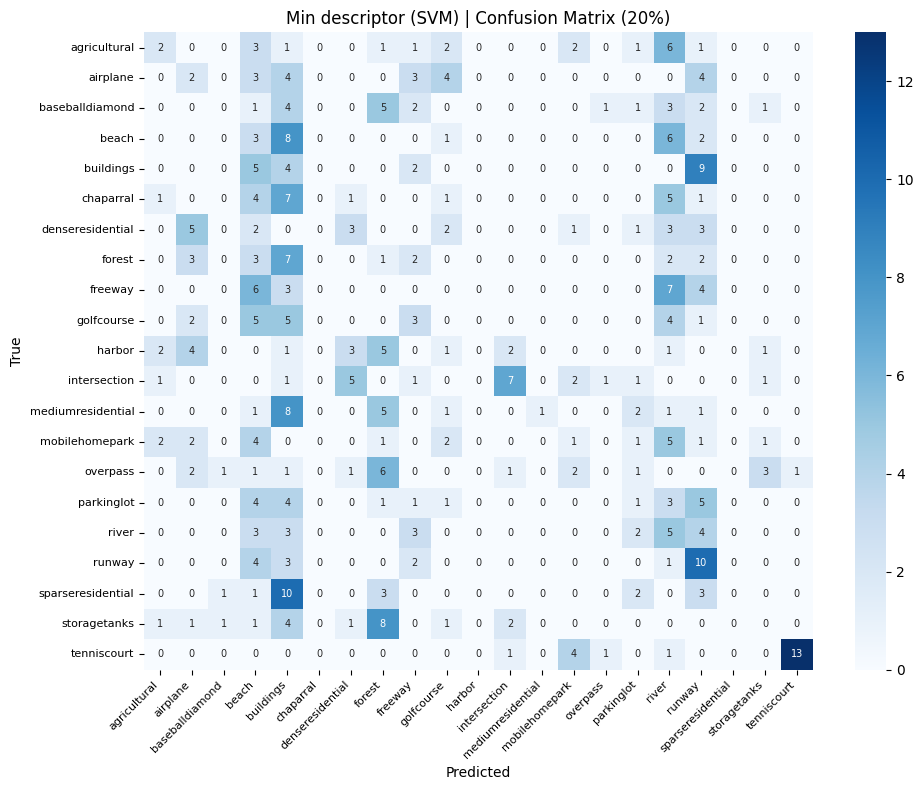

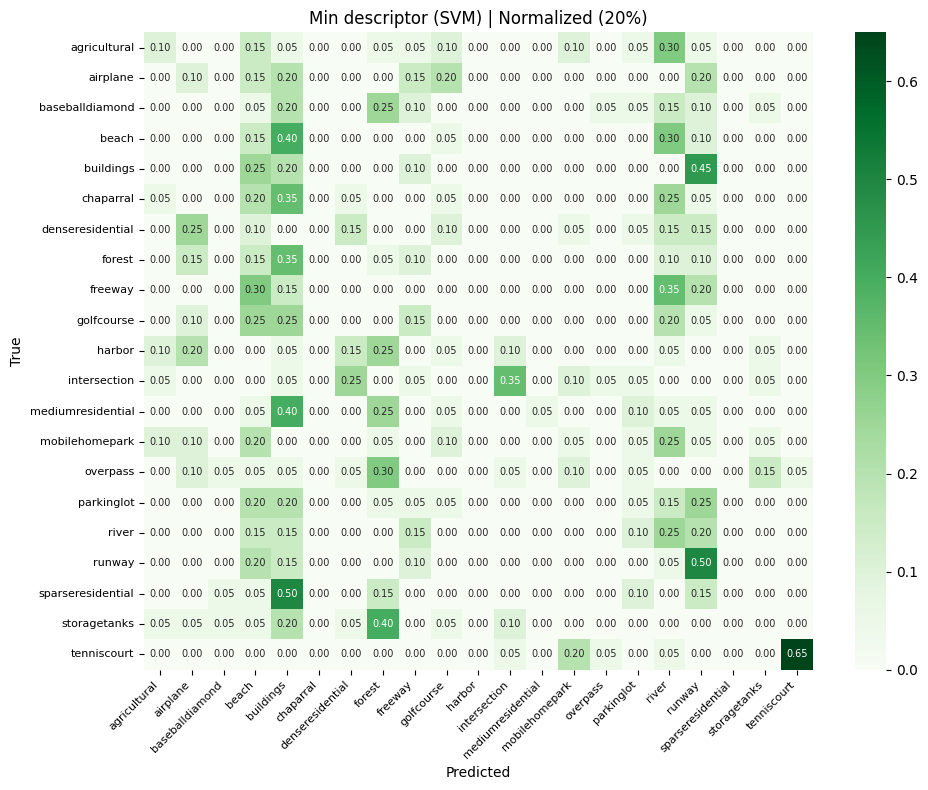

Min descriptor (SVM) — Test 40% → 🎯 11.56%


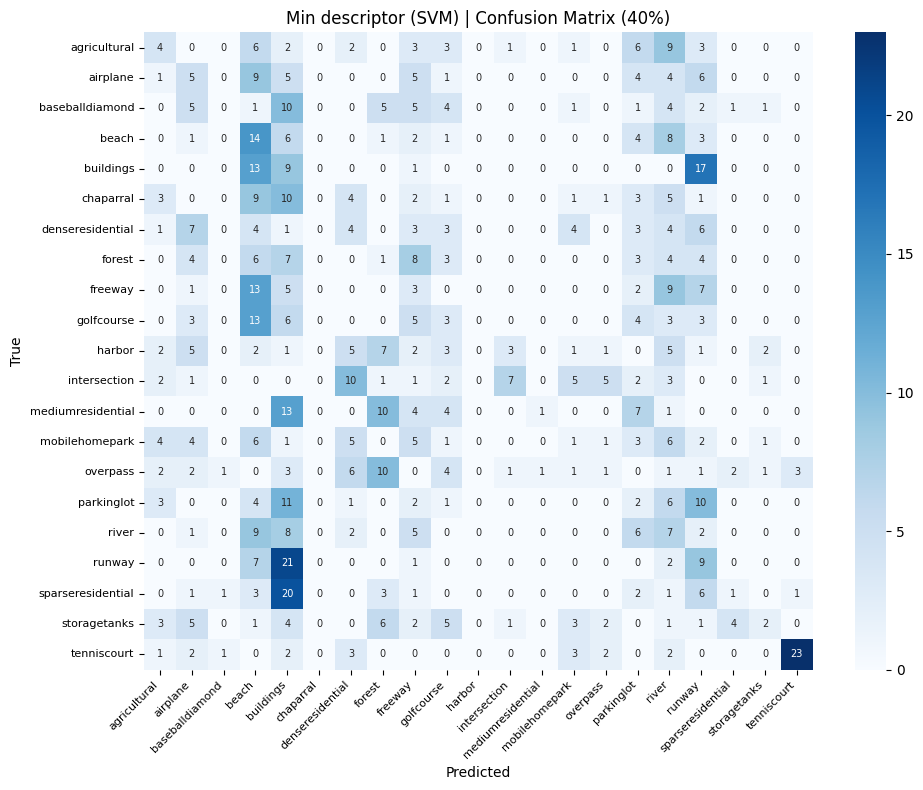

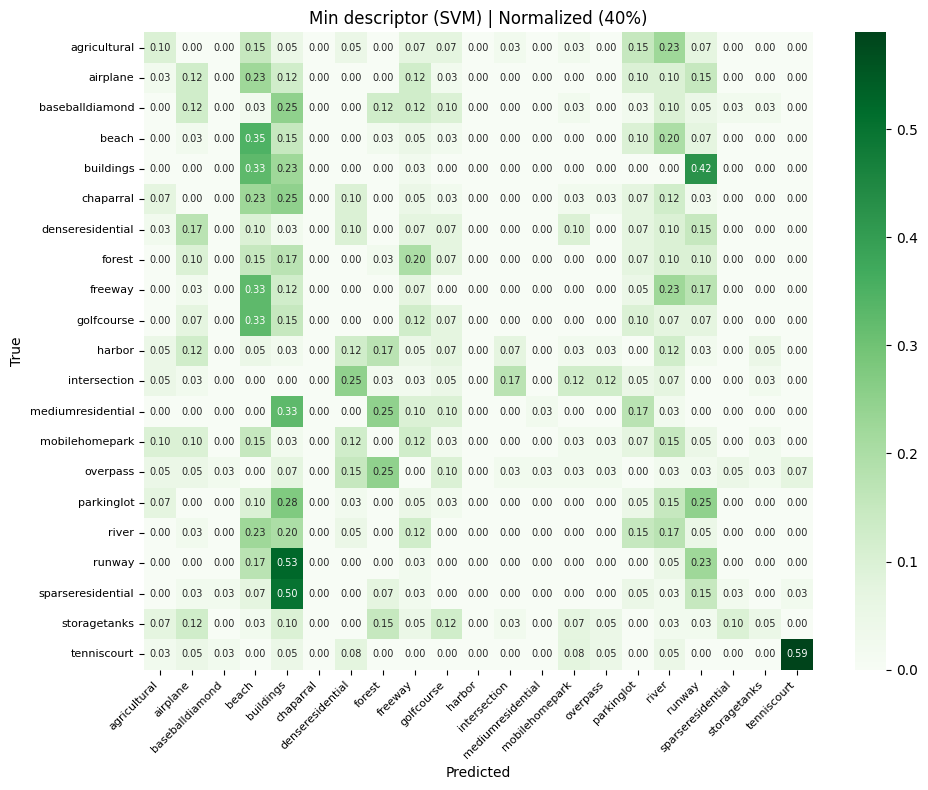

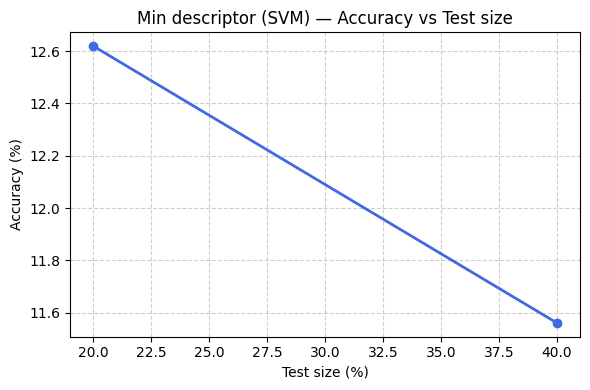

Evaluating BoVW histograms:   0%|          | 0/4 [00:00<?, ?it/s]

BoVW (k=10) (KNN) — Test 20% → 🎯 40.00%


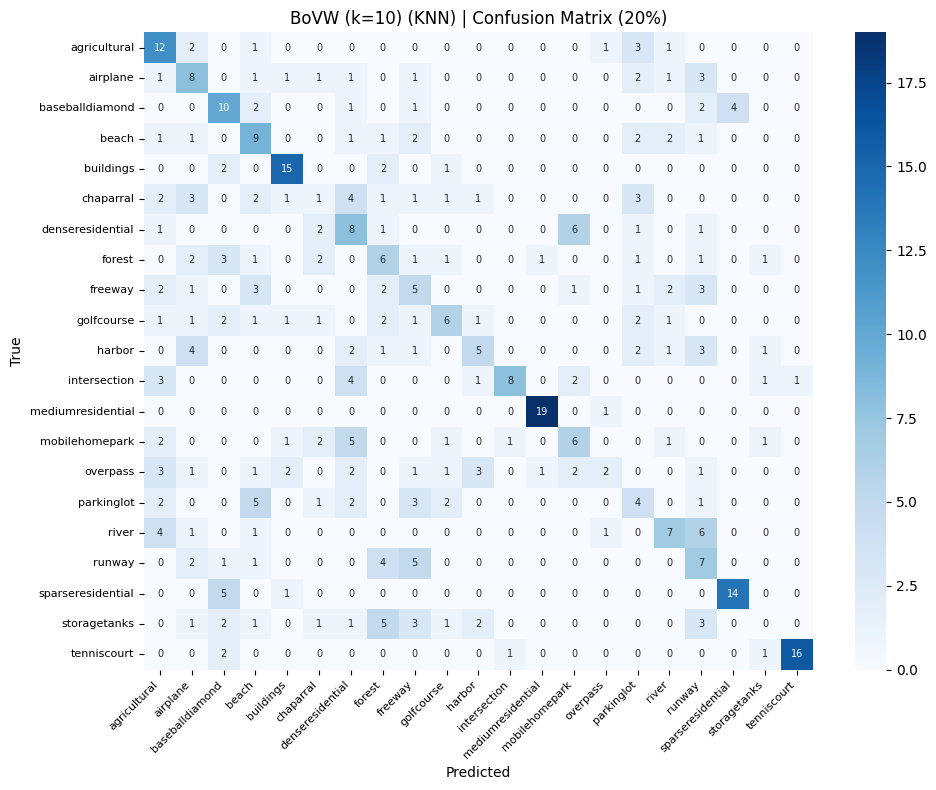

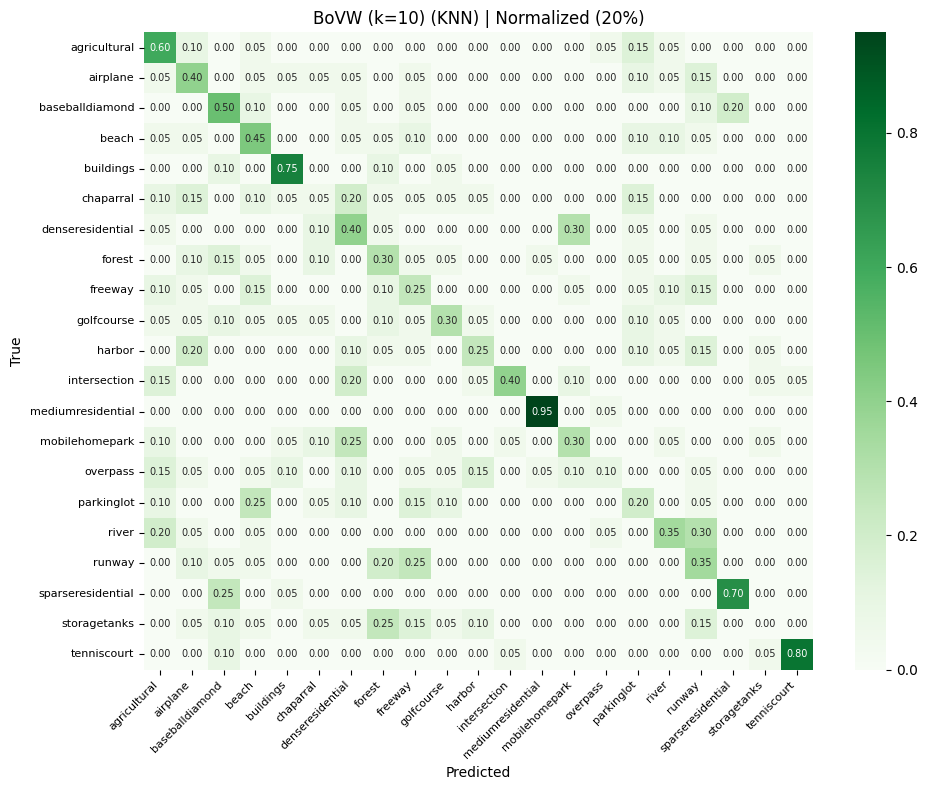

BoVW (k=10) (KNN) — Test 40% → 🎯 39.33%


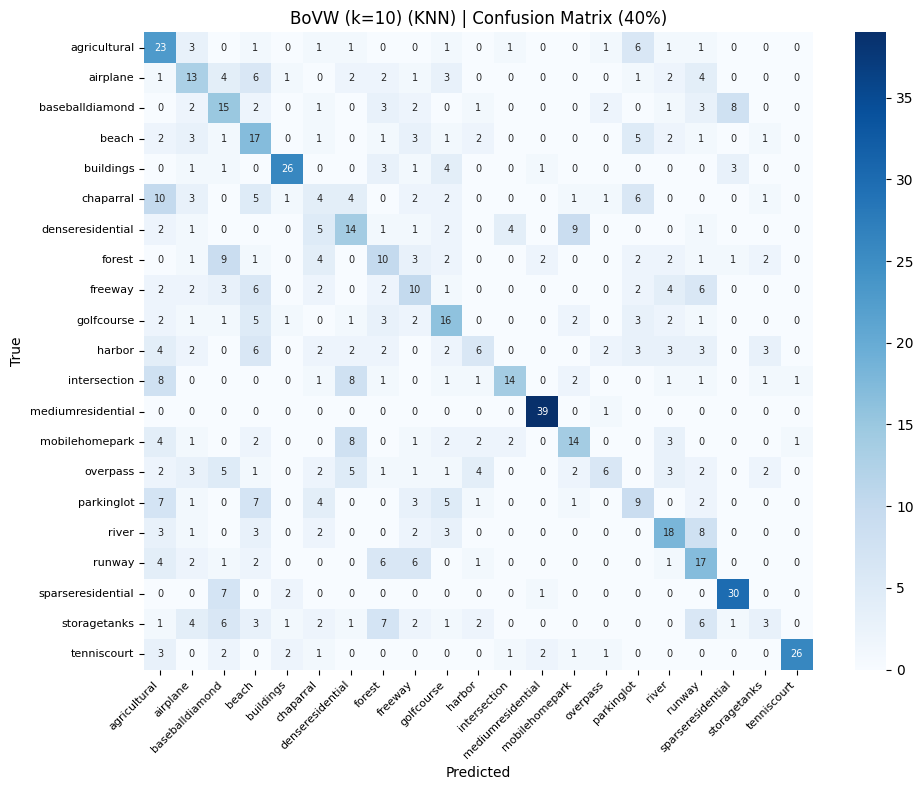

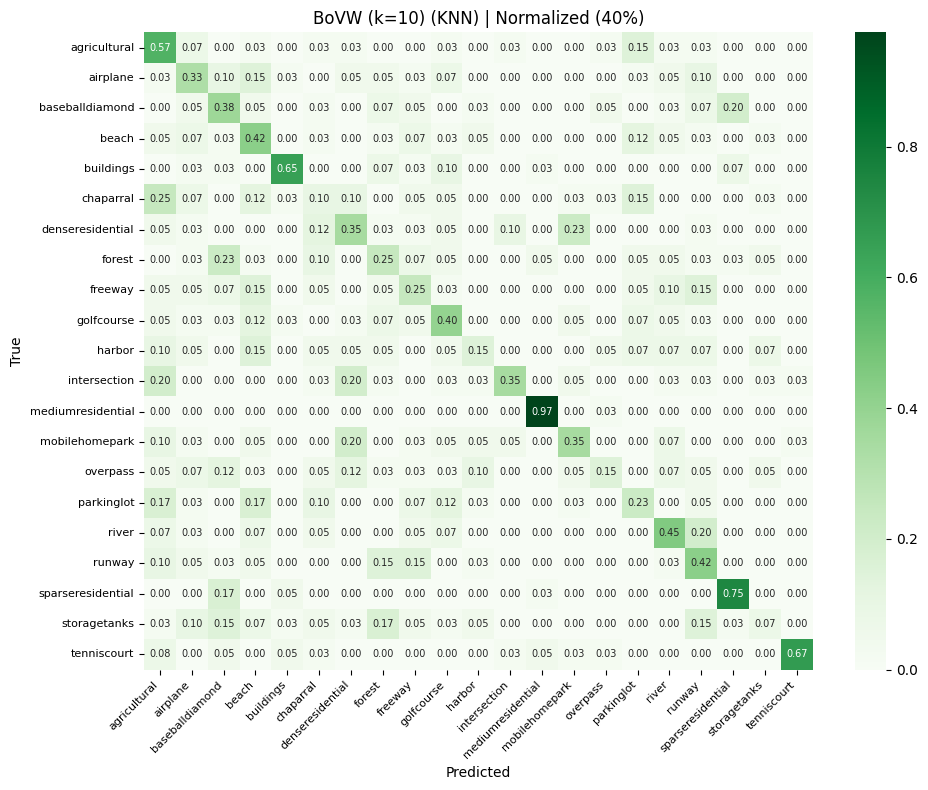

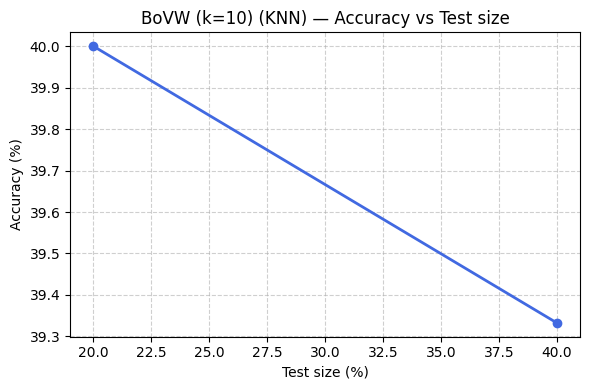

BoVW (k=10) (SVM) — Test 20% → 🎯 44.76%


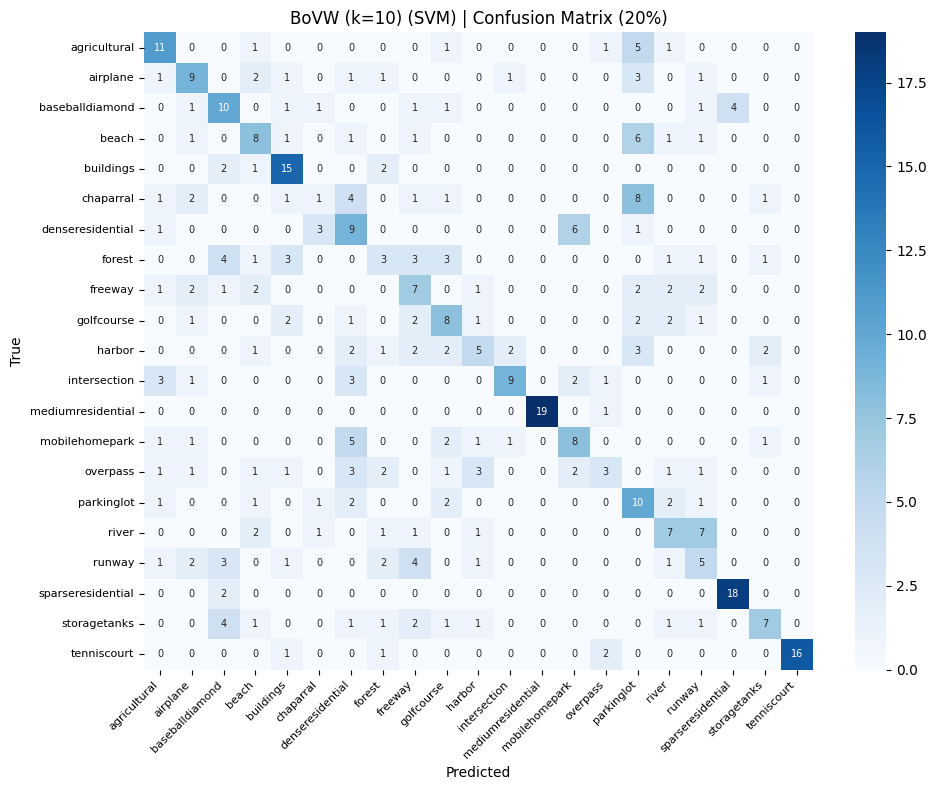

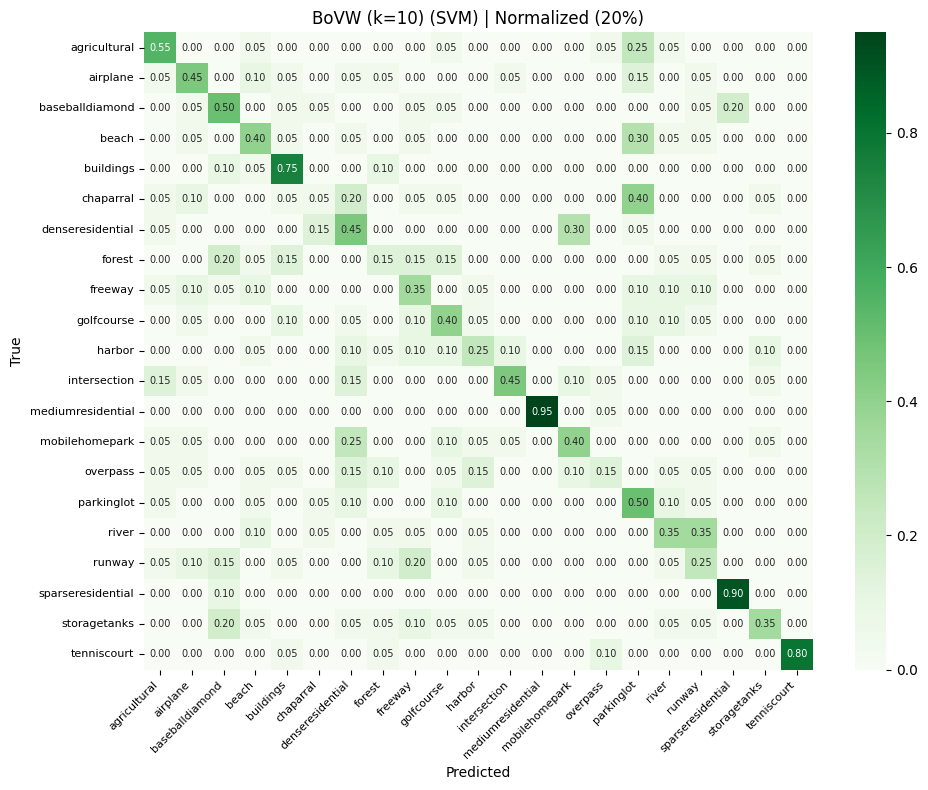

BoVW (k=10) (SVM) — Test 40% → 🎯 44.10%


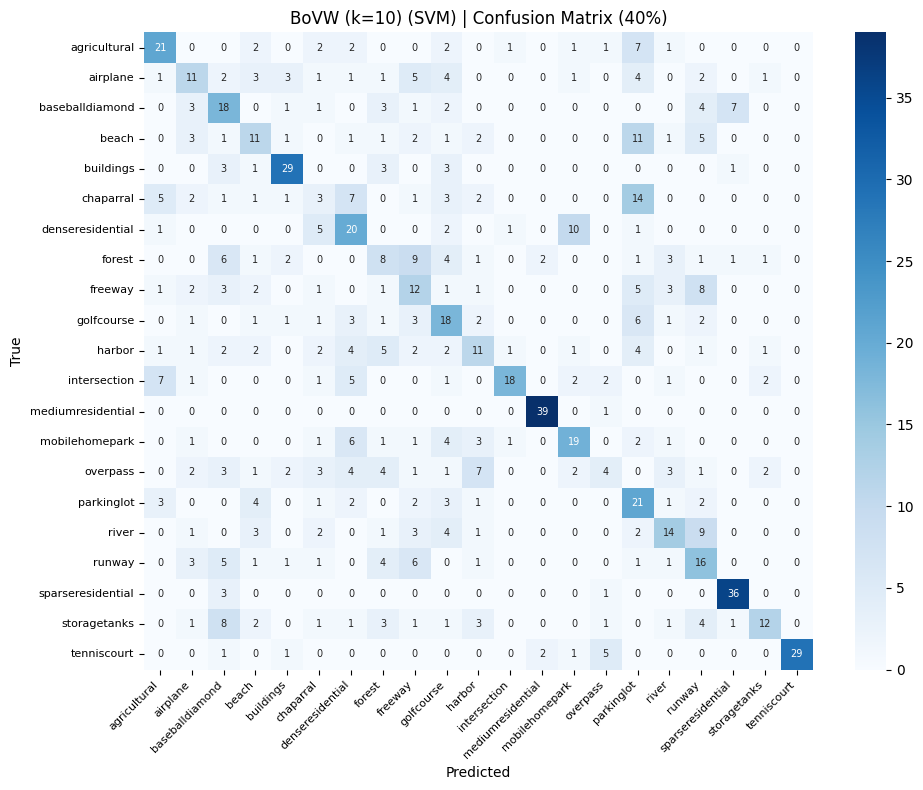

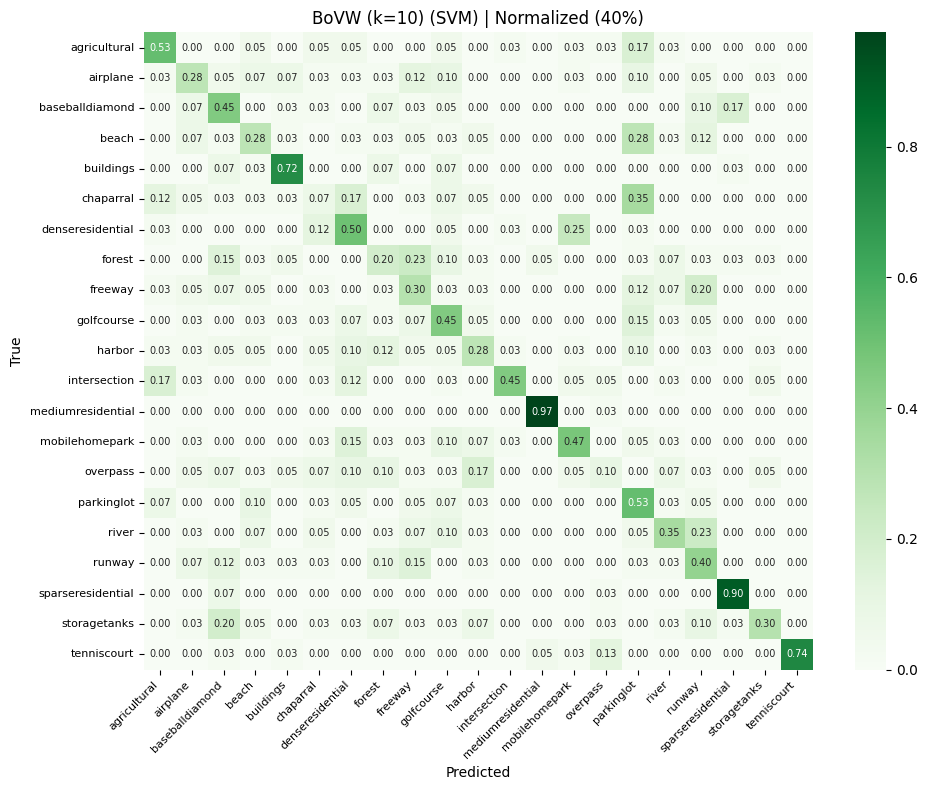

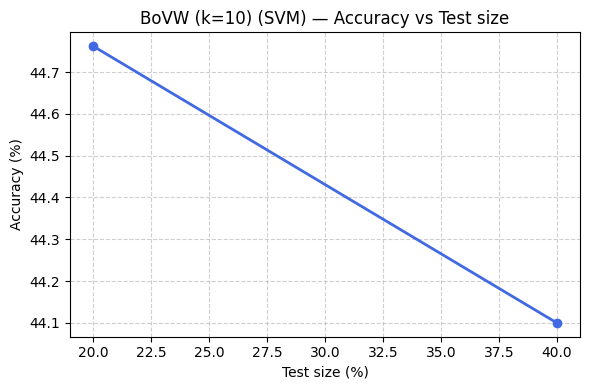

Evaluating BoVW histograms:  25%|██▌       | 1/4 [00:09<00:27,  9.17s/it]

BoVW (k=50) (KNN) — Test 20% → 🎯 54.76%


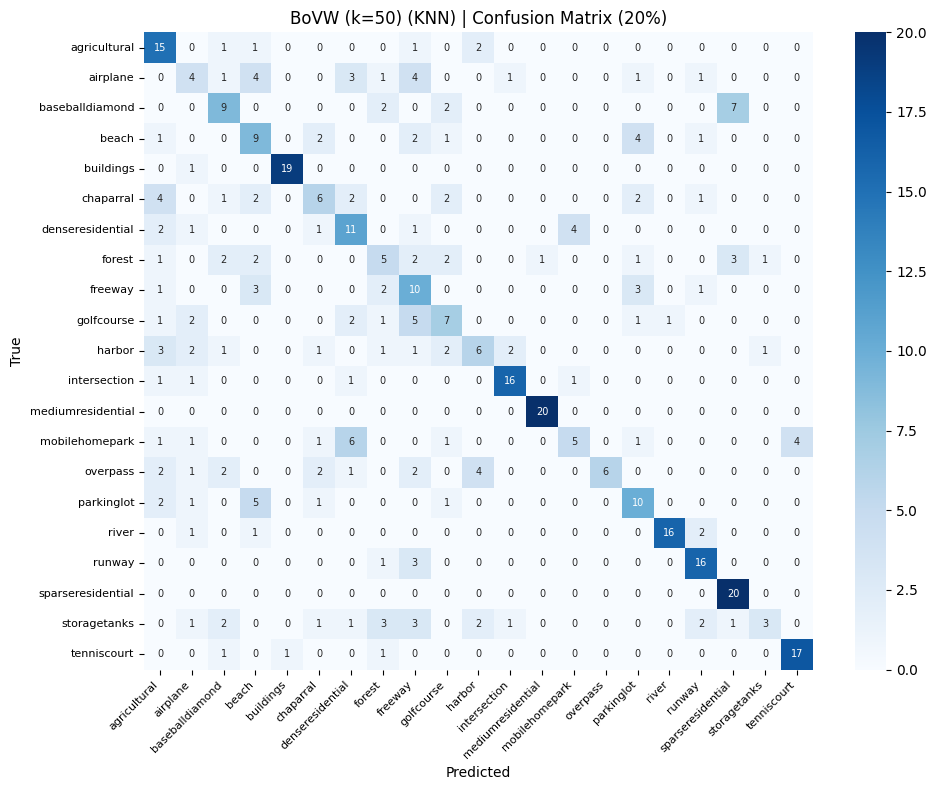

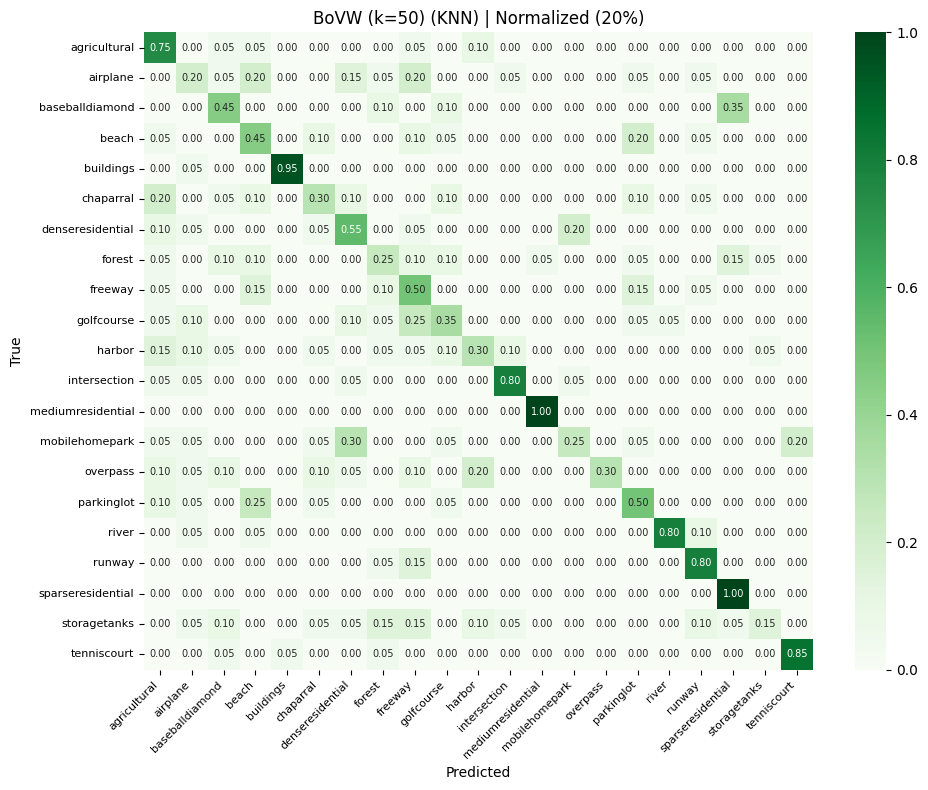

BoVW (k=50) (KNN) — Test 40% → 🎯 52.92%


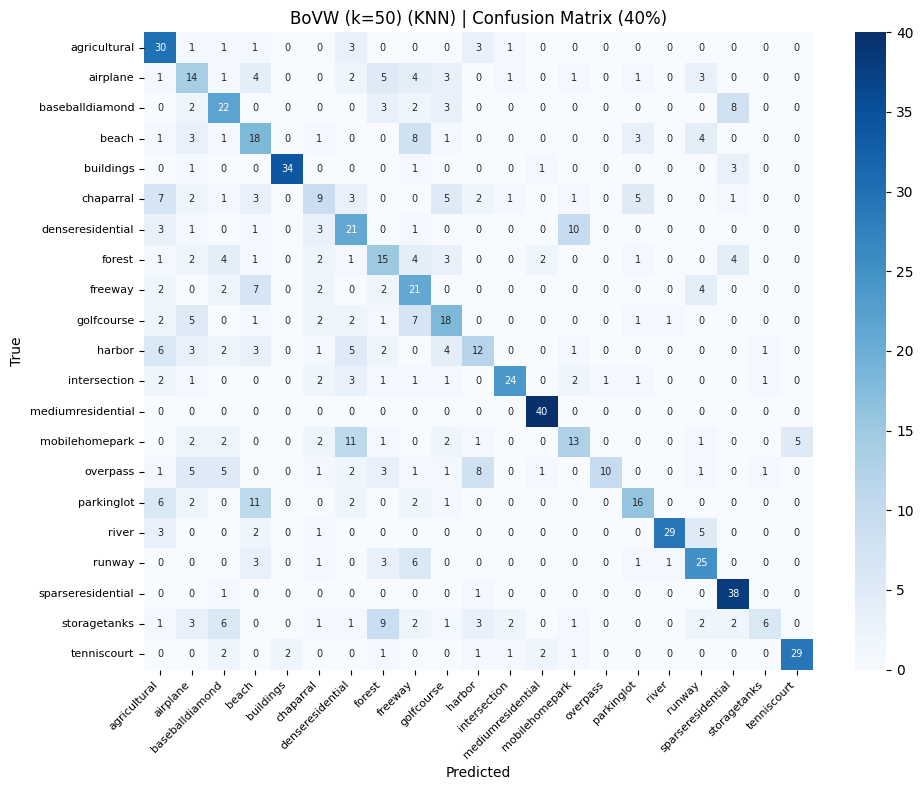

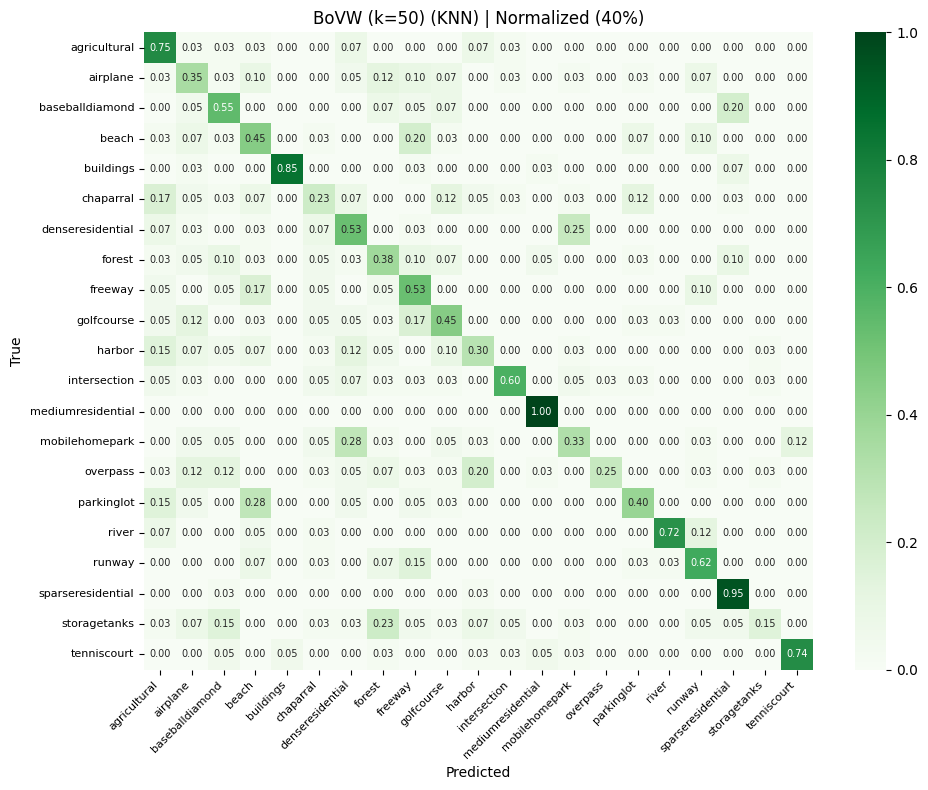

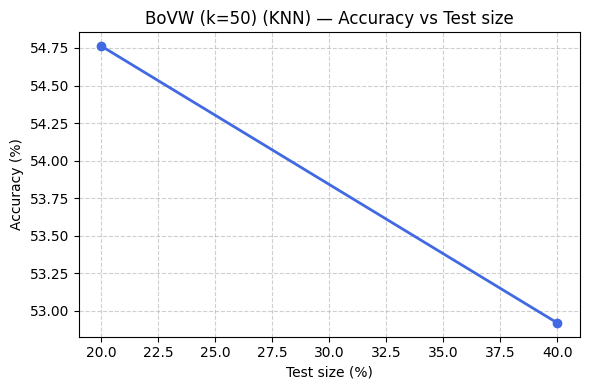

BoVW (k=50) (SVM) — Test 20% → 🎯 63.57%


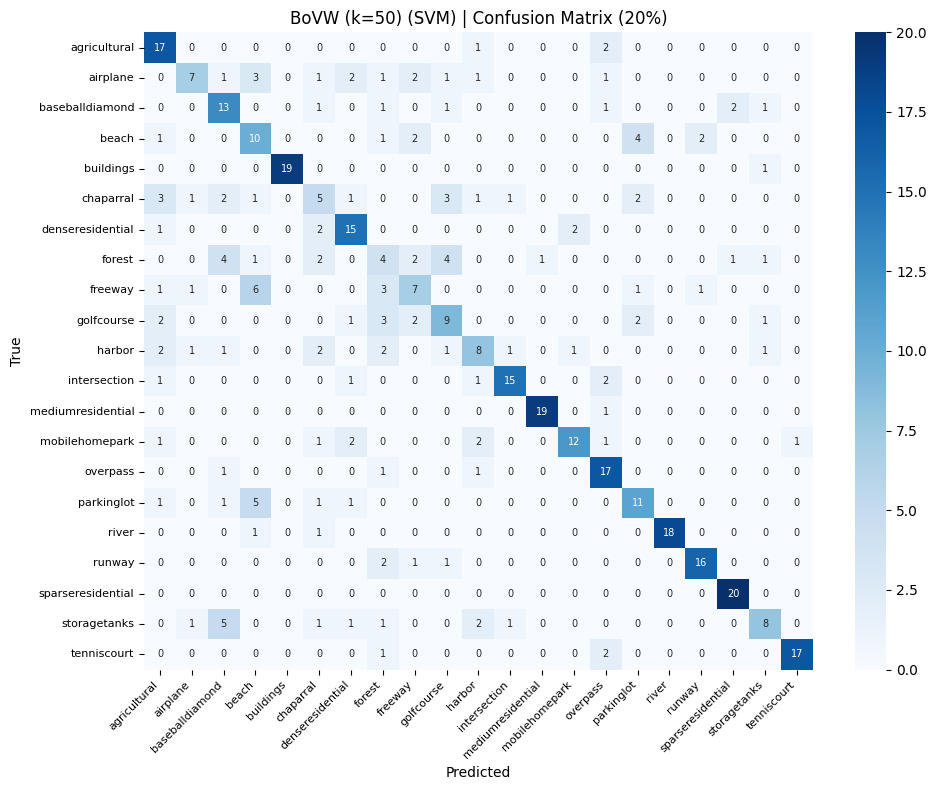

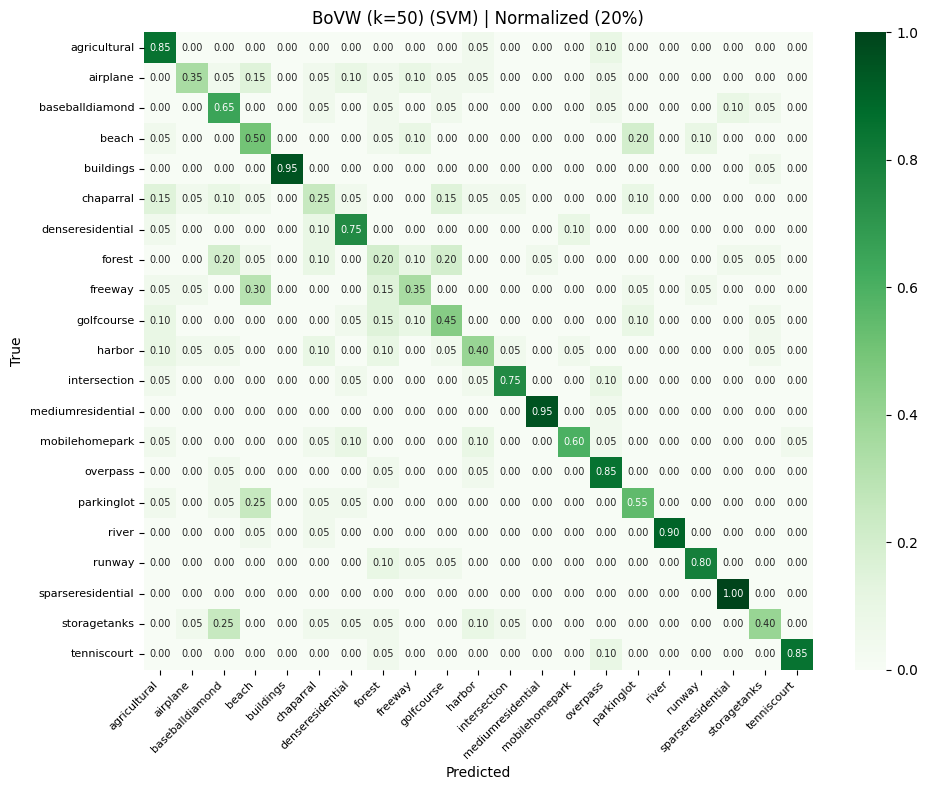

BoVW (k=50) (SVM) — Test 40% → 🎯 60.55%


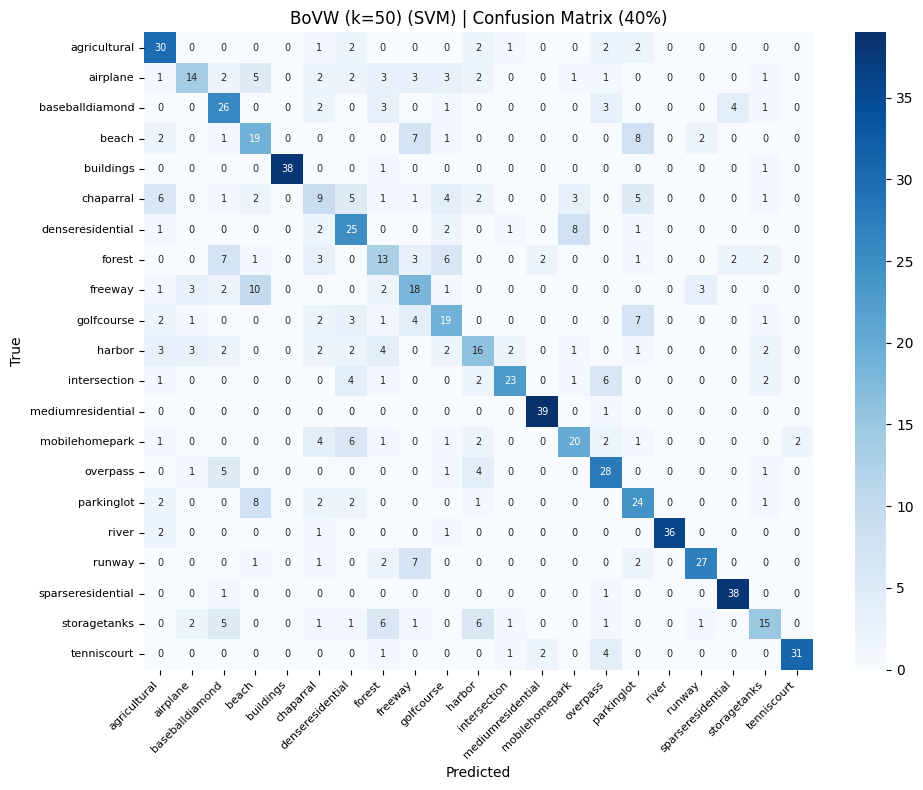

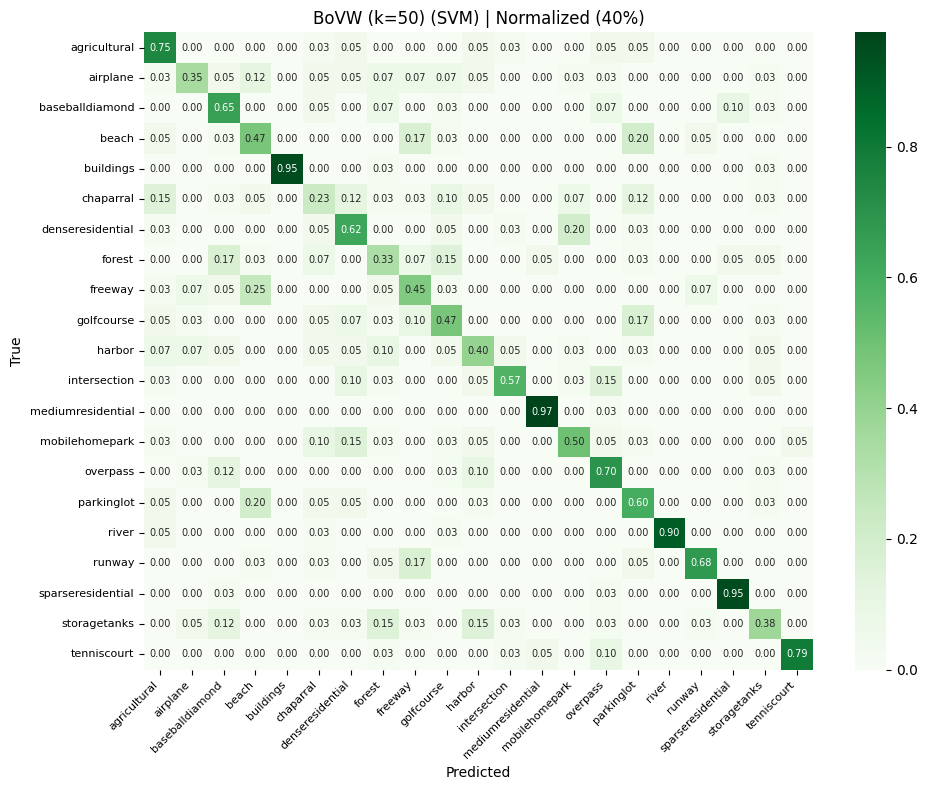

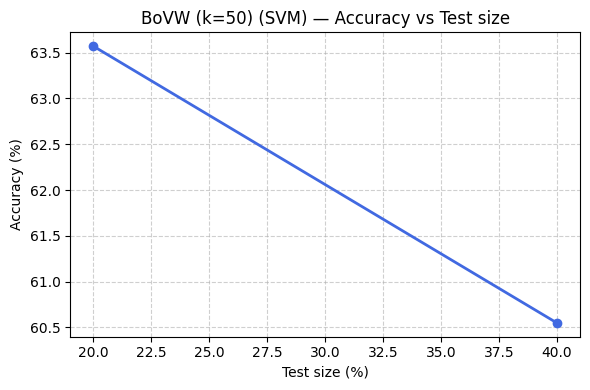

Evaluating BoVW histograms:  50%|█████     | 2/4 [00:18<00:18,  9.08s/it]

BoVW (k=100) (KNN) — Test 20% → 🎯 54.76%


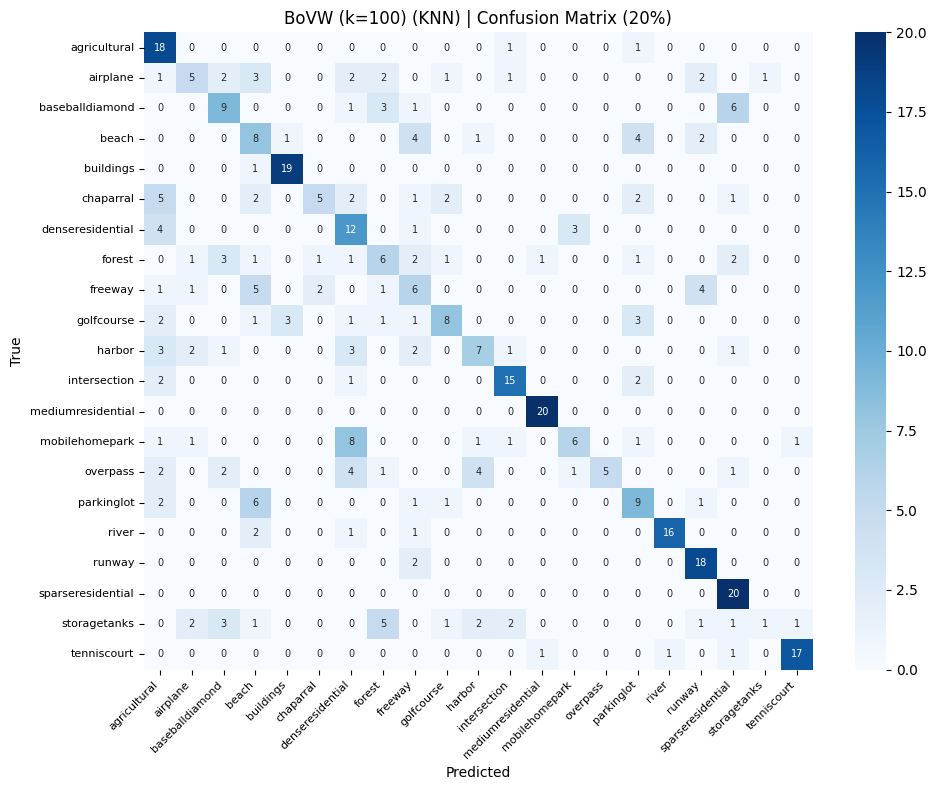

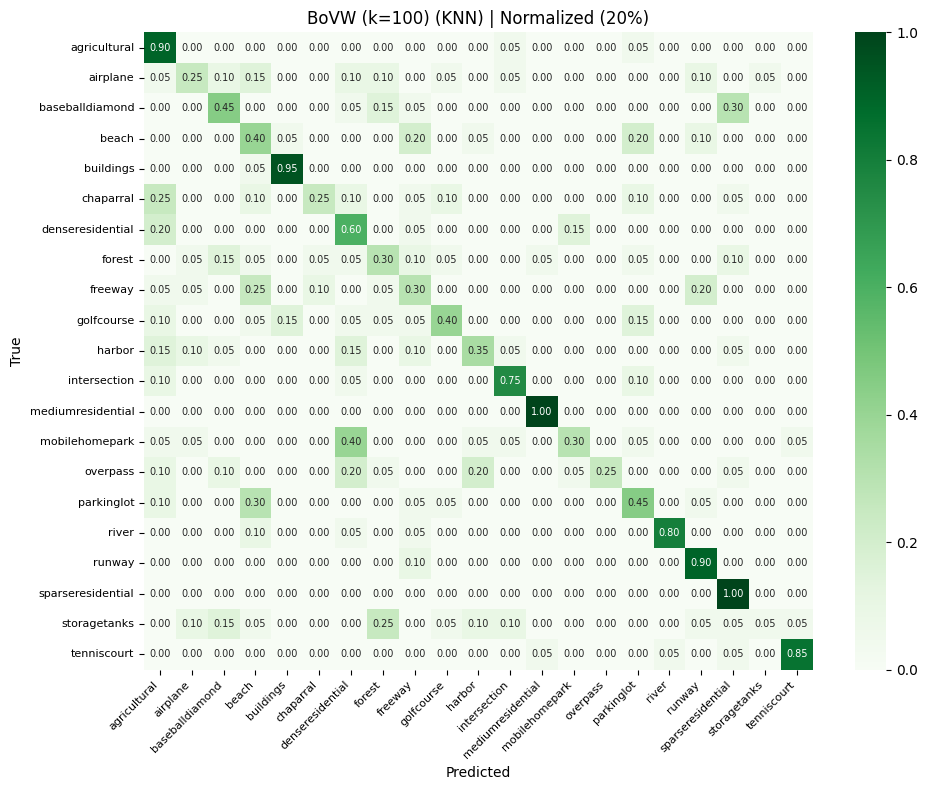

BoVW (k=100) (KNN) — Test 40% → 🎯 53.64%


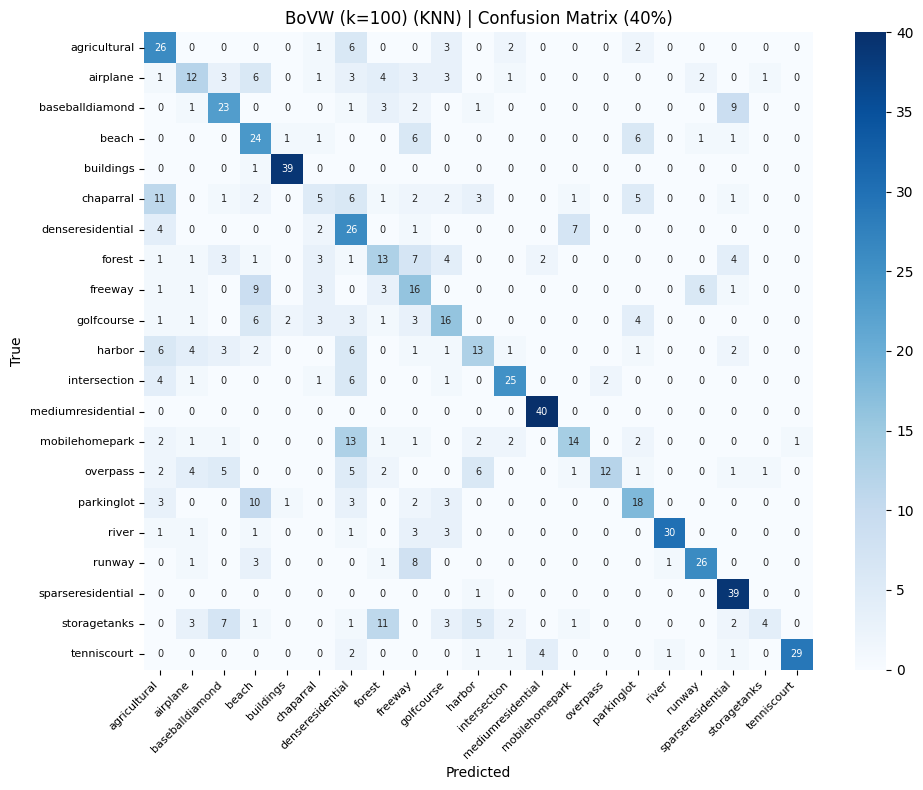

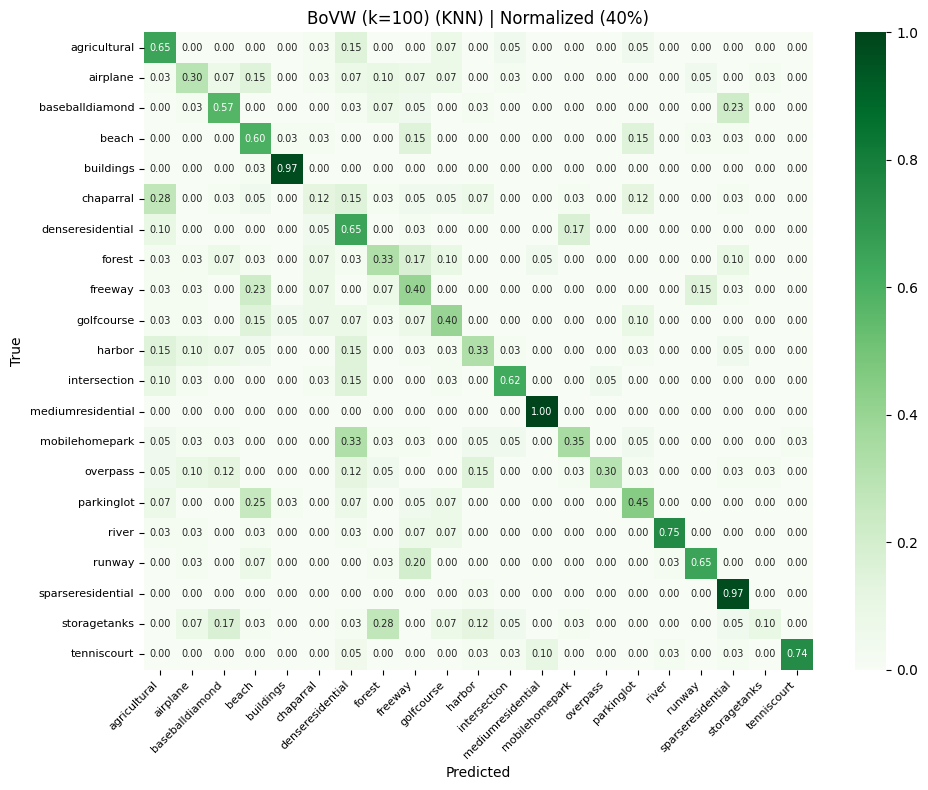

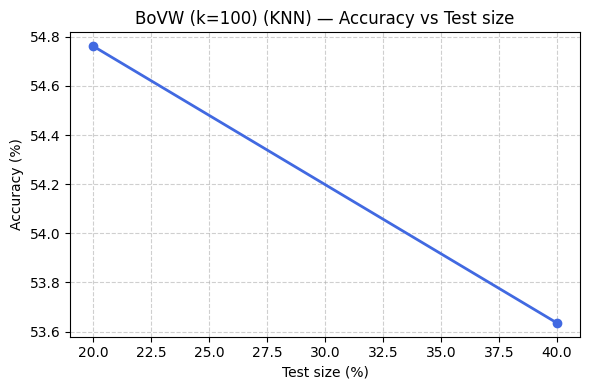

BoVW (k=100) (SVM) — Test 20% → 🎯 70.00%


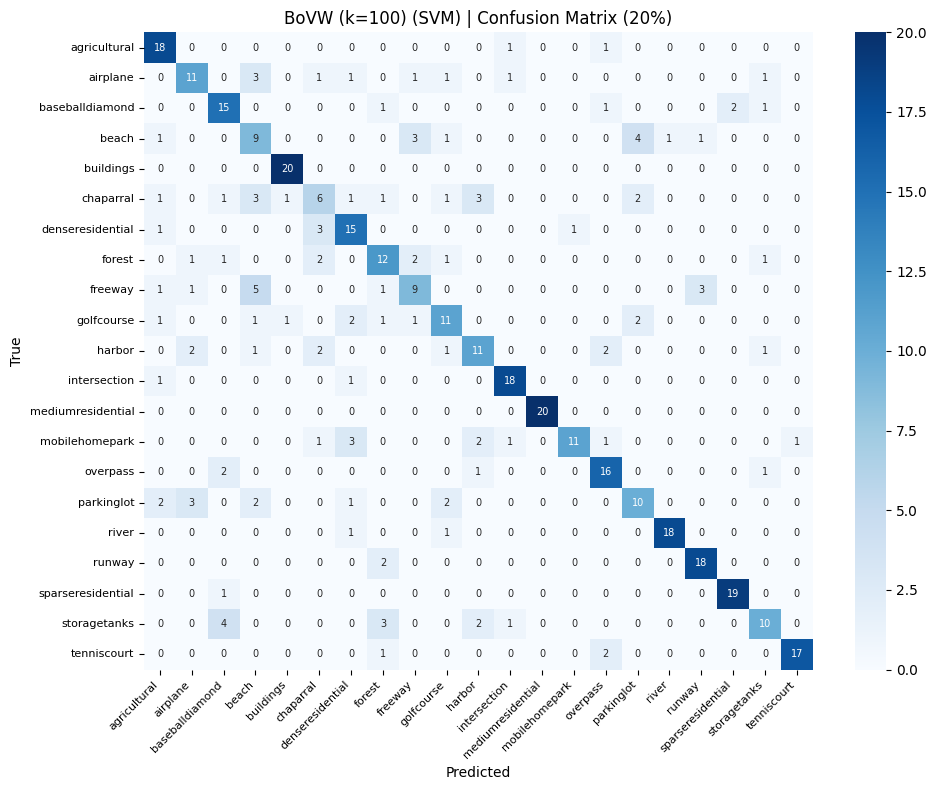

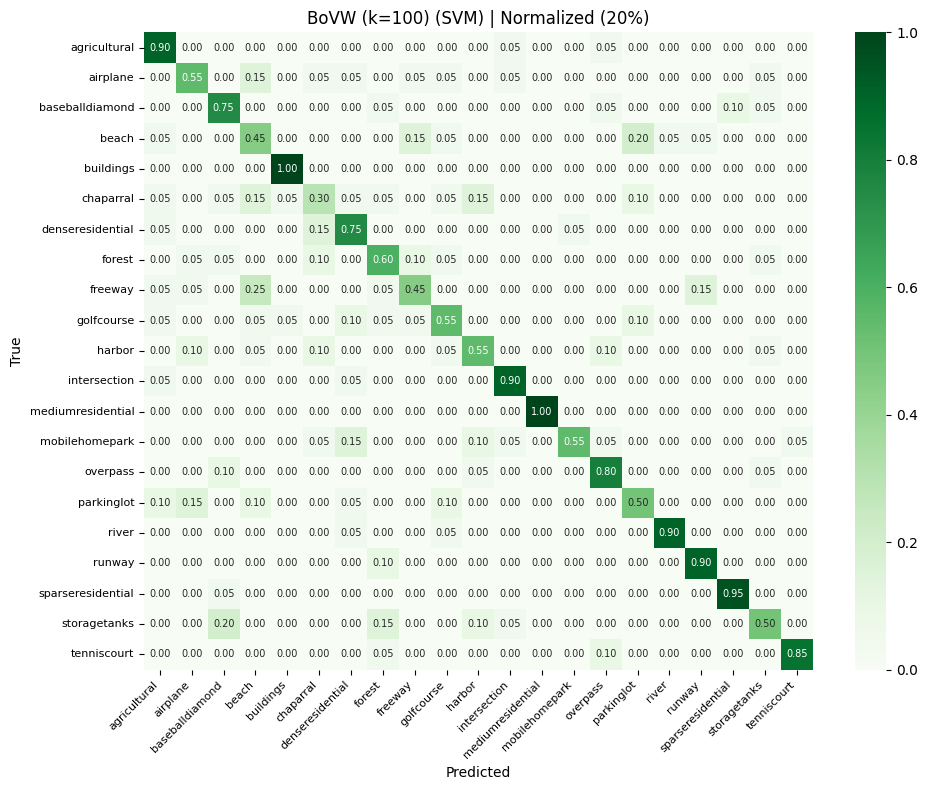

BoVW (k=100) (SVM) — Test 40% → 🎯 65.32%


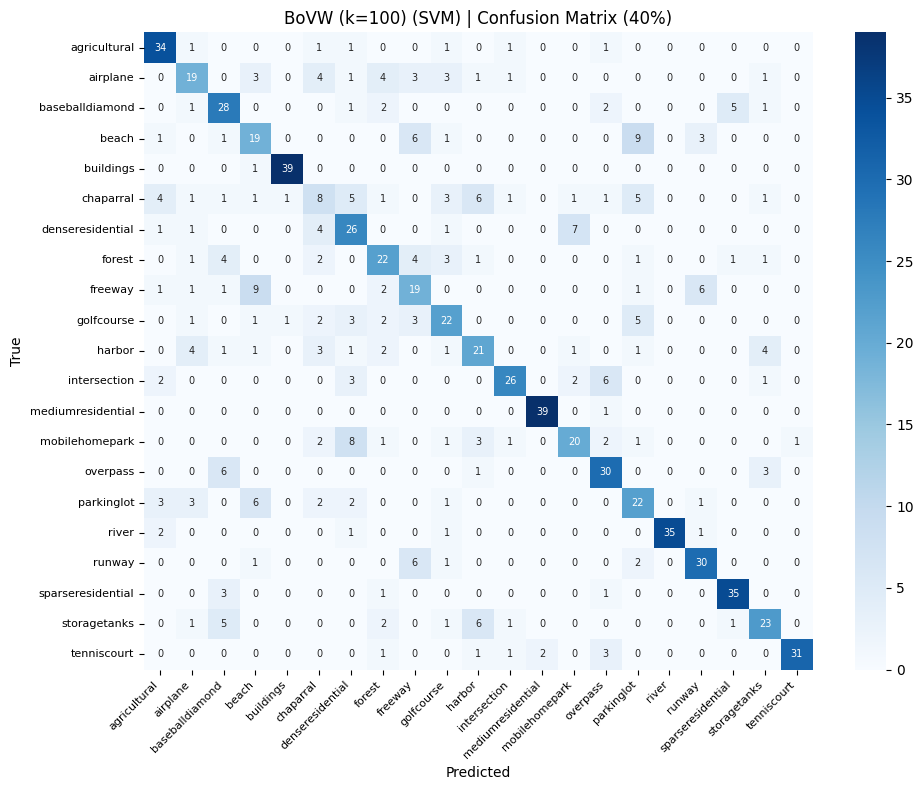

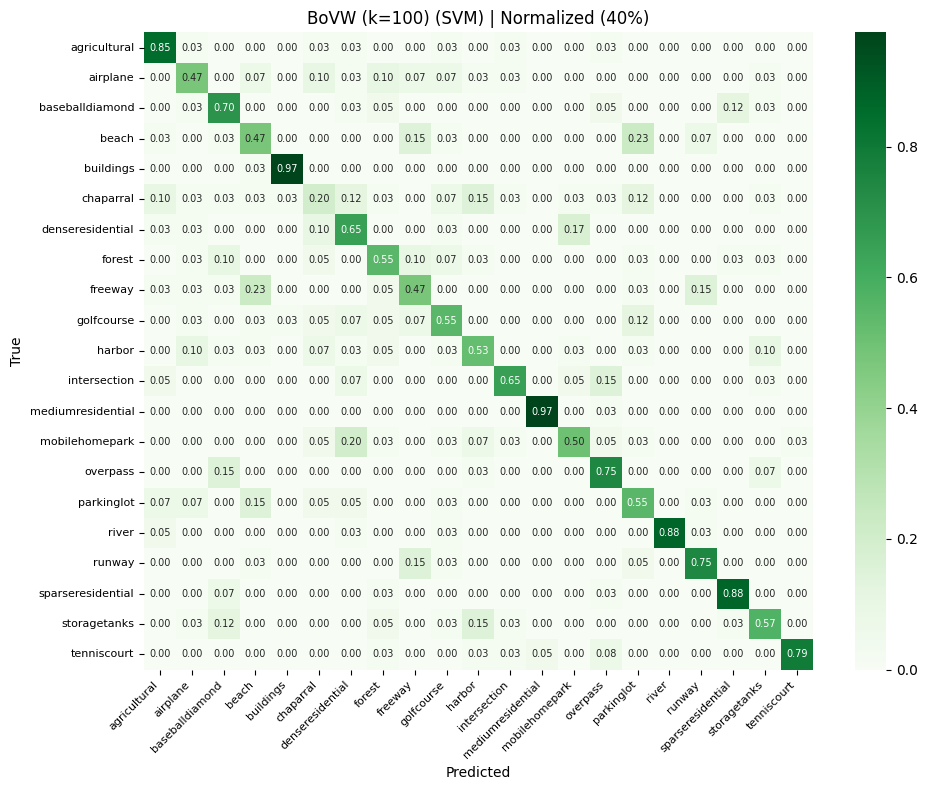

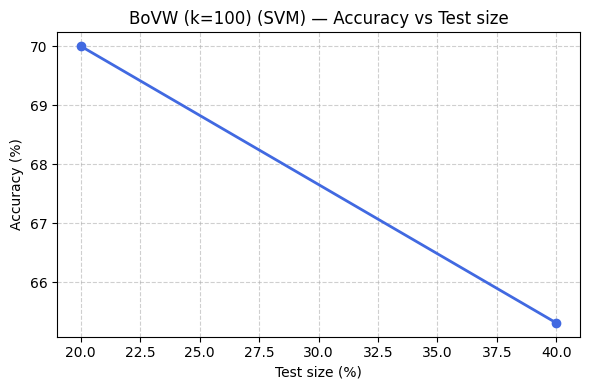

Evaluating BoVW histograms:  75%|███████▌  | 3/4 [00:27<00:09,  9.19s/it]

BoVW (k=150) (KNN) — Test 20% → 🎯 57.62%


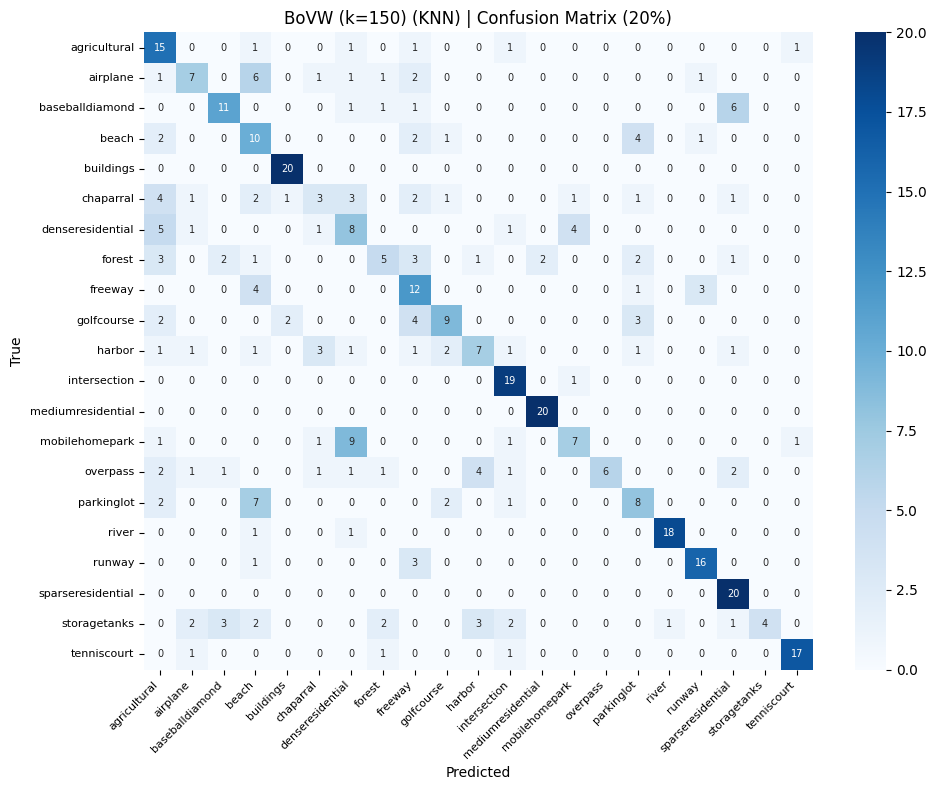

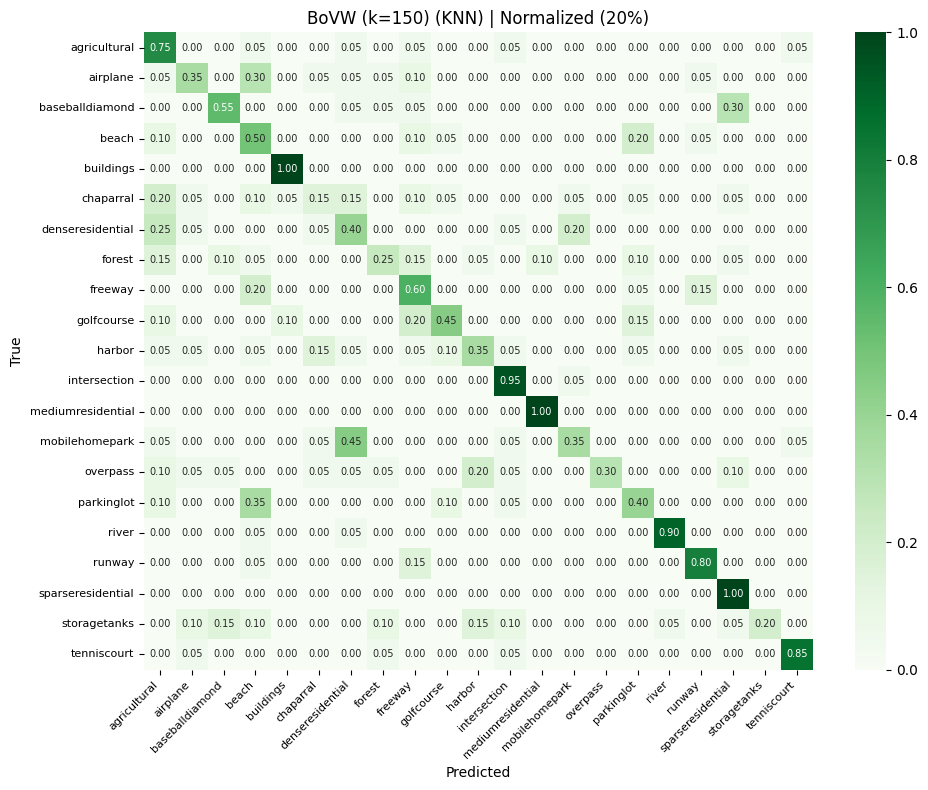

BoVW (k=150) (KNN) — Test 40% → 🎯 54.95%


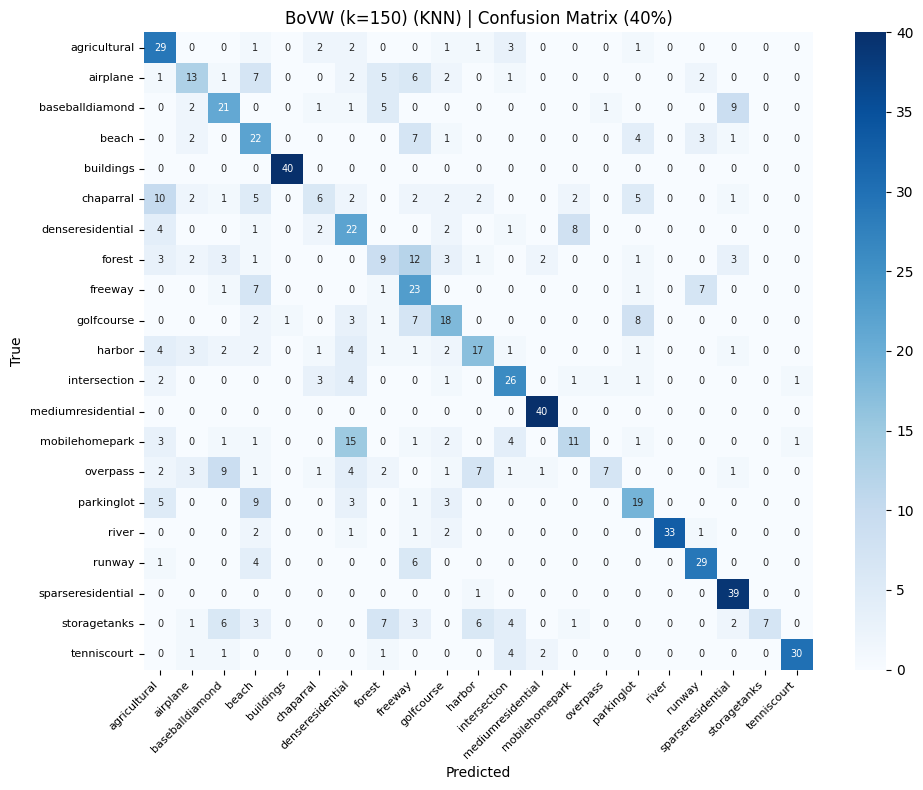

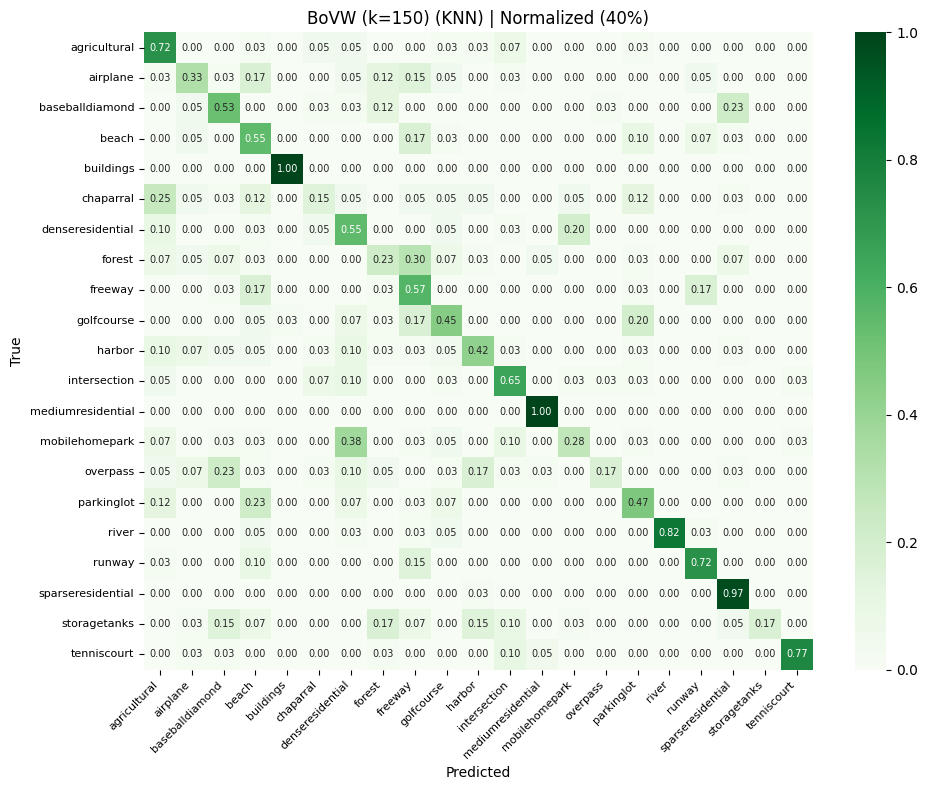

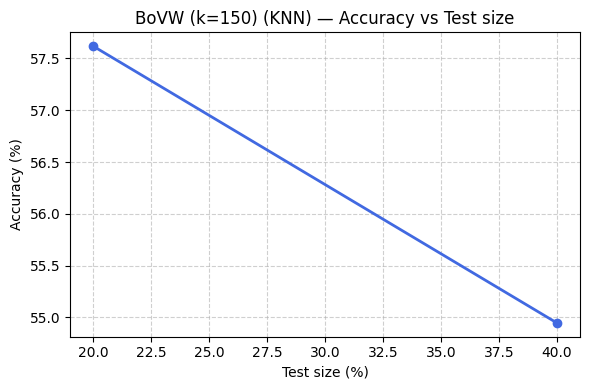

BoVW (k=150) (SVM) — Test 20% → 🎯 71.43%


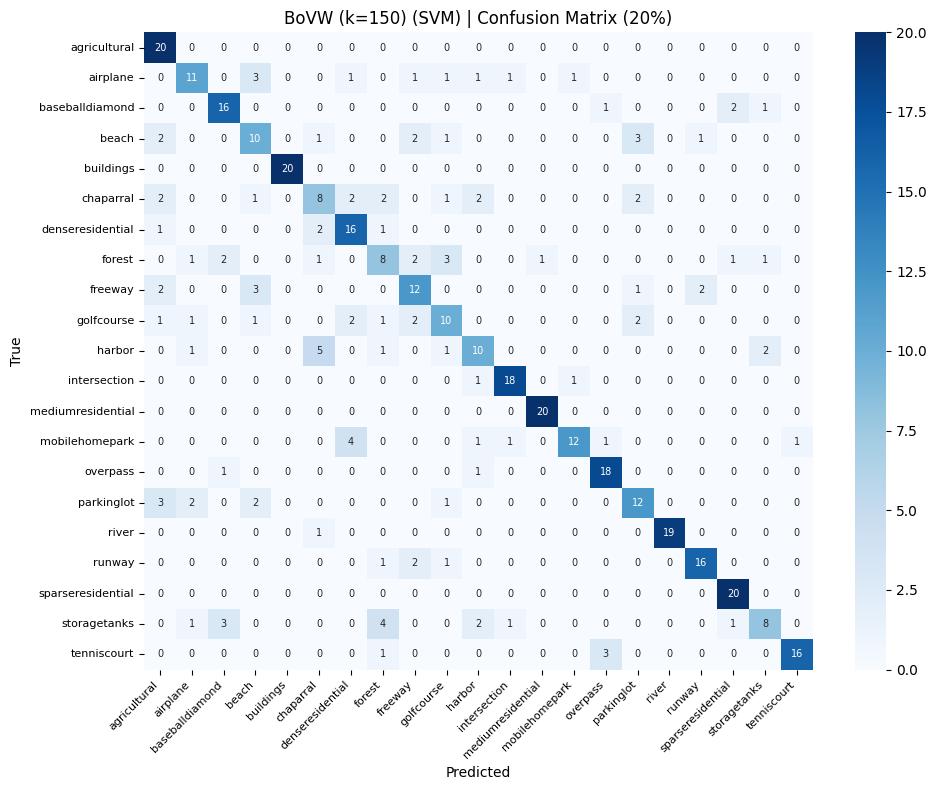

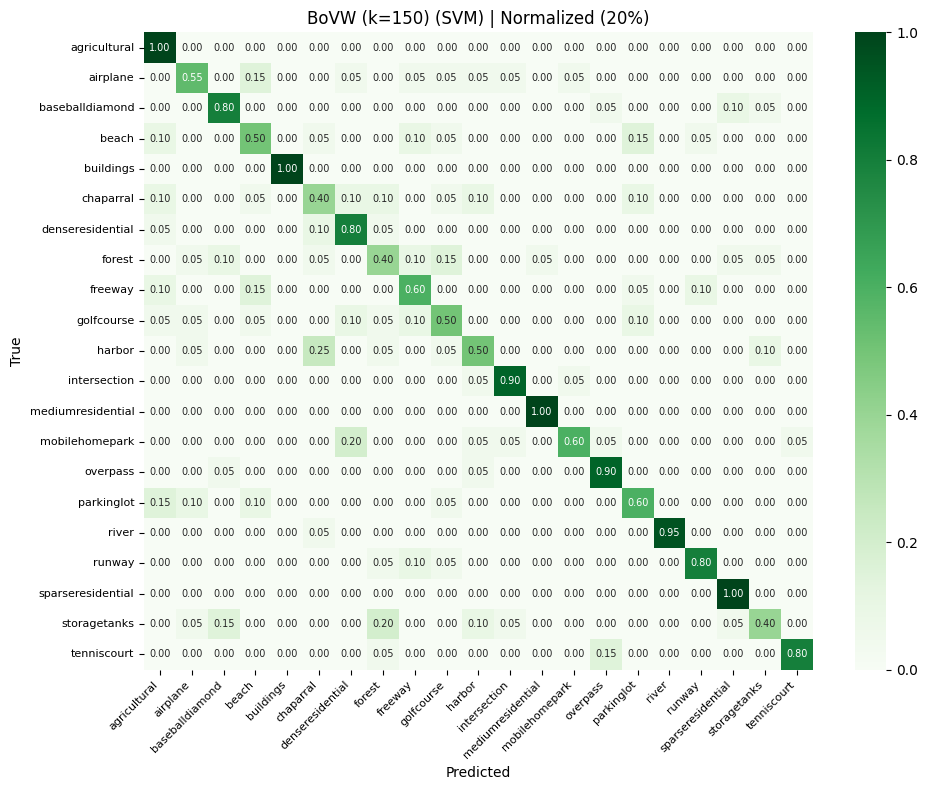

BoVW (k=150) (SVM) — Test 40% → 🎯 67.34%


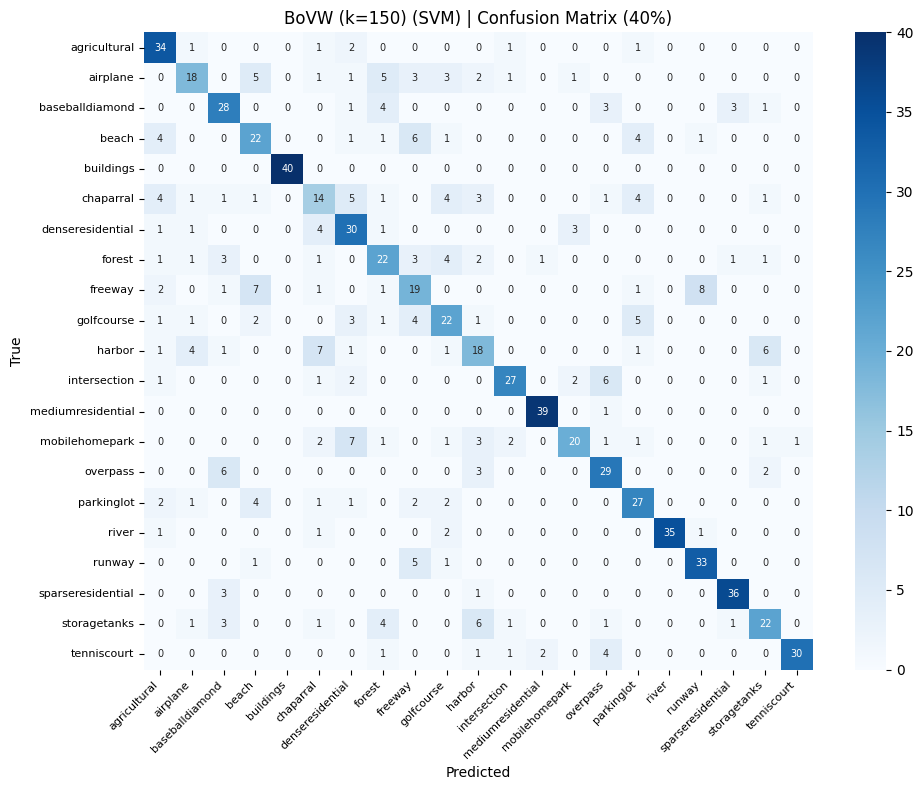

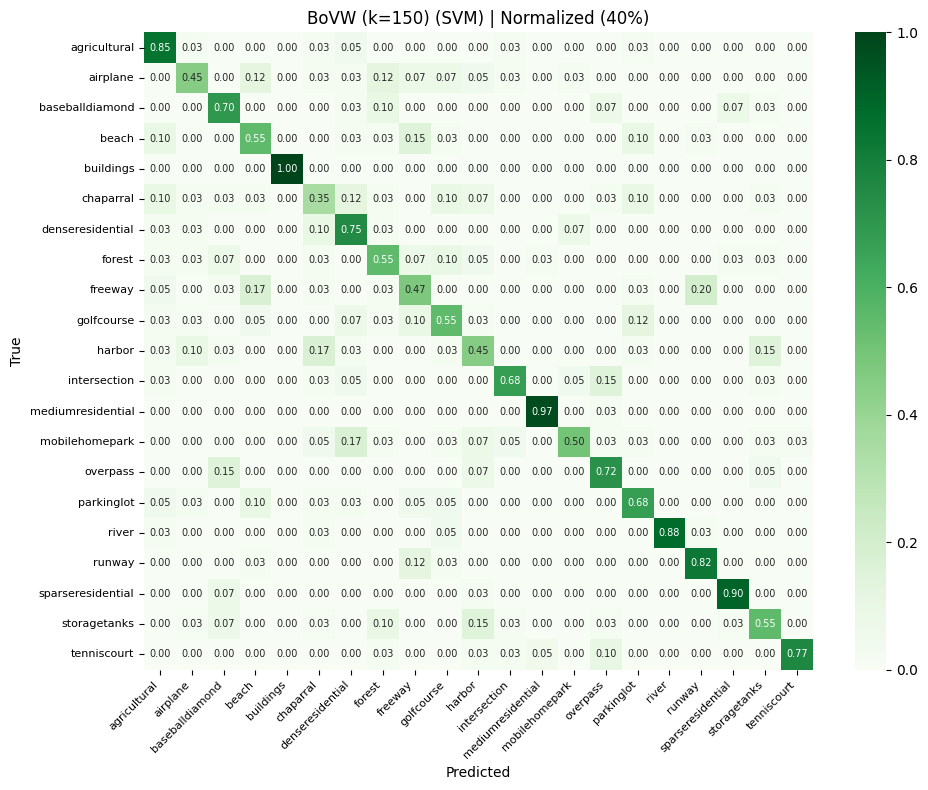

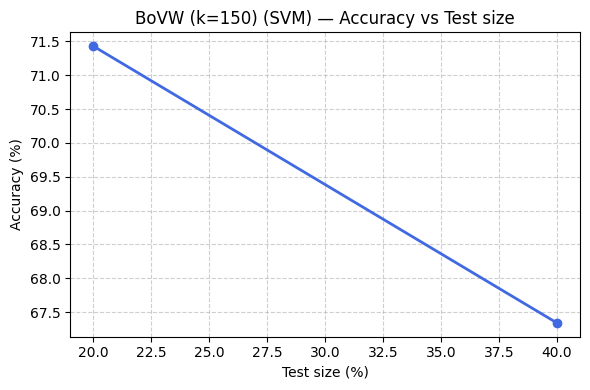

Evaluating BoVW histograms: 100%|██████████| 4/4 [00:36<00:00,  9.21s/it]


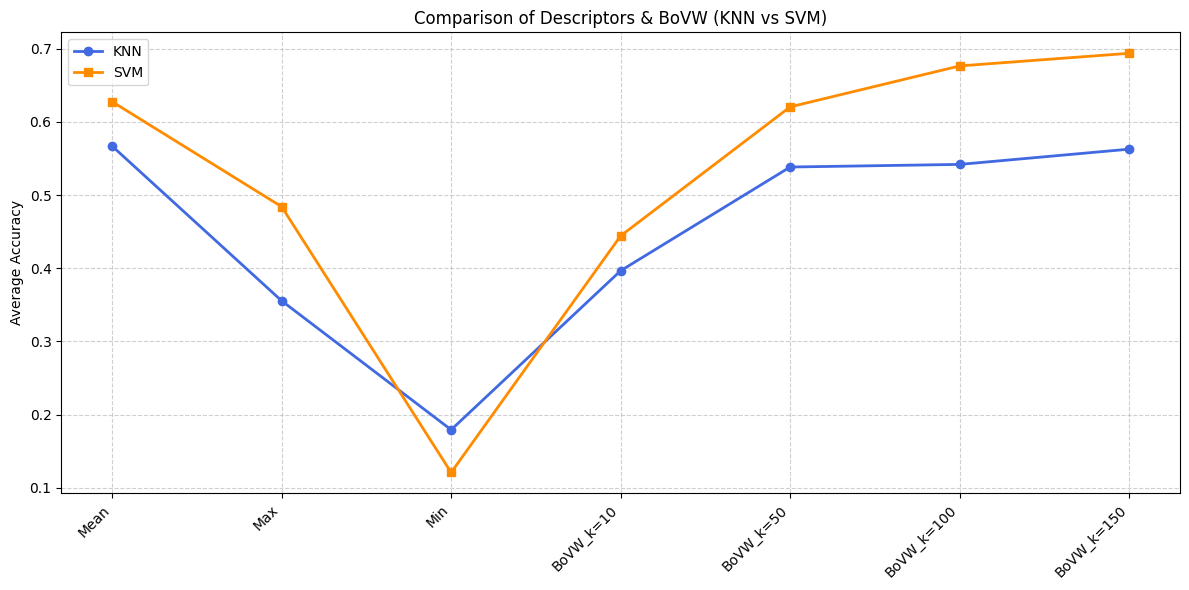


✅ Evaluation Summary:

Method                      KNN        SVM
---------------------------------------------
Mean                 0.5670     0.6277
Max                  0.3556     0.4842
Min                  0.1793     0.1209
BoVW_k=10            0.3967     0.4443
BoVW_k=50            0.5384     0.6206
BoVW_k=100           0.5420     0.6766
BoVW_k=150           0.5628     0.6939


In [48]:
results = evaluate_all_methods(
    descriptors_dict=descriptors_dict,
    y=y,
    bovw_histograms=bovw_histograms,
    cluster_numbers=[10, 50, 100, 150],
    test_sizes=[0.2, 0.4],
    class_names=class_names,
    show_confusion=True,
    show_plot=True
)